# MSIN0097 Predictive Analysis GroupWork

# Prediction Project

This notebook starts by importing standard Python libraries for data analysis and machine learning, then loads the local dataset and shows a quick first look at the data.


## Section 1: Setup

In [51]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

pd.set_option("display.max_columns", 100)


In [52]:
df = pd.read_csv("../data/data_2.csv", low_memory=False)
display(df.head())


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256970e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820930e-04,1.165010e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897850e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

## Section 2: Initial Data Audit and Unsupervised Cleaning

### 2.1 Load the Dataset

**Goal:**
Create the main working dataframe for EDA and cleaning, confirm that the target variable Bankrupt? is present, and establish the dataset shape before any unsupervised cleaning.


In [53]:
# Load dataset from local file

file_path = Path("../data/data_2.csv")
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset loaded successfully.
Shape: 6819 rows, 96 columns


In [54]:
df_eda = df.copy()

target_col = "Bankrupt?"

if target_col not in df_eda.columns:
    raise ValueError(f"Target variable '{target_col}' is not found in the dataset.")

original_shape = df_eda.shape
original_shape


(6819, 96)

**Interpretation:** df_eda is kept as the main working dataframe so the later notebook remains compatible. This section does not perform any imputation or train/test splitting.

### 2.2 Inspect Dataset Structure

### Goal
Review the basic structure of the dataset, including column names, variable types, and overall descriptive statistics, before any cleaning decisions are made.

In [55]:
print("Dataset shape:", df_eda.shape)
print("\nColumn names:")
display(pd.DataFrame({"column_name": df_eda.columns}))

print("\nVariable types:")
display(df_eda.dtypes.value_counts())


Dataset shape: (6819, 96)

Column names:


,column_name
0,Bankrupt?
1,ROA(C) before interest and depreciation befor...
2,ROA(A) before interest and % after tax
3,ROA(B) before interest and depreciation after...
4,Operating Gross Margin
...,...
91,Liability to Equity
92,Degree of Financial Leverage (DFL)
93,Interest Coverage Ratio (Interest expense to ...
94,Net Income Flag



Variable types:


float64    93
int64       3
Name: count, dtype: int64

In [56]:
df_eda.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


**Interpretation:** This is a descriptive inspection only. It helps identify unusual ranges, inconsistent scales, and likely data-quality problems without changing the dataset.

### 2.3 Check Standard Missingness and Duplicate Structure

**Goal:**  Summarise standard missing values, duplicated rows, and duplicated columns before applying any dataset-specific cleaning rules.


In [57]:
missing_summary_standard = pd.DataFrame({
    "missing_count": df_eda.isnull().sum(),
    "missing_percent": df_eda.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

missing_summary_standard


,missing_count,missing_percent
Bankrupt?,0,0.0
ROA(C) before interest and depreciation before interest,0,0.0
ROA(A) before interest and % after tax,0,0.0
ROA(B) before interest and depreciation after tax,0,0.0
Operating Gross Margin,0,0.0
...,...,...
Liability to Equity,0,0.0
Degree of Financial Leverage (DFL),0,0.0
Interest Coverage Ratio (Interest expense to EBIT),0,0.0
Net Income Flag,0,0.0


In [58]:
duplicated_rows = df_eda.duplicated().sum()
duplicated_columns = df_eda.columns[df_eda.columns.duplicated()].tolist()

pd.DataFrame({
    "check": ["duplicated_rows", "duplicated_columns"],
    "value": [duplicated_rows, len(duplicated_columns)]
})


,check,value
0,duplicated_rows,0
1,duplicated_columns,0


**Interpretation:** This subsection checks only what is already explicitly missing or duplicated. It does not yet handle dataset-specific invalid numeric values.

### 2.4 Recode Invalid Extreme Numeric Values to Missing
**Goal:** Recode obviously invalid extreme numeric values to missing values using a conservative dataset-specific rule before any missingness-based filtering.

In [59]:
extreme_value_threshold = 1_000_000

numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
numeric_feature_cols = [col for col in numeric_cols if col != target_col]

extreme_recode_log = []

for col in numeric_feature_cols:
    invalid_mask = df_eda[col] > extreme_value_threshold
    recoded_count = int(invalid_mask.sum())

    extreme_recode_log.append({
        "variable": col,
        "values_recoded_to_missing": recoded_count
    })

    if recoded_count > 0:
        df_eda.loc[invalid_mask, col] = np.nan

extreme_recode_log = pd.DataFrame(extreme_recode_log).sort_values(
    by="values_recoded_to_missing",
    ascending=False
).reset_index(drop=True)

extreme_recode_log


,variable,values_recoded_to_missing
0,Total Asset Growth Rate,6016
1,Cash Turnover Rate,4238
2,Research and development expense rate,4033
3,Inventory Turnover Rate (times),2946
4,Quick Asset Turnover Rate,2383
...,...,...
90,Liability to Equity,0
91,Degree of Financial Leverage (DFL),0
92,Interest Coverage Ratio (Interest expense to ...,0
93,Net Income Flag,0


**Interpretation:** This step is still unsupervised cleaning, not modelling. It treats very large values as invalid data rather than attempting to learn anything from the target or from future test observations.

### 2.5 Remove Clearly Non-Predictive and Structurally Unusable Variables

**Goal:** Remove variables that are clearly non-predictive administrative fields, constant columns, or columns with excessive missingness after invalid values have been recode

In [60]:
removed_variables = []

# Remove obvious identifier-like columns if they exist
non_predictive_keywords = ["id", "index", "unnamed"]
candidate_non_predictive = []

for col in df_eda.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in non_predictive_keywords):
        if col != target_col:
            candidate_non_predictive.append(col)

for col in candidate_non_predictive:
    removed_variables.append({
        "variable": col,
        "reason": "Clearly non-predictive identifier/index field"
    })

if candidate_non_predictive:
    df_eda = df_eda.drop(columns=candidate_non_predictive, errors="ignore")

# Remove constant columns
constant_cols = [
    col for col in df_eda.columns
    if col != target_col and df_eda[col].nunique(dropna=False) <= 1
]

for col in constant_cols:
    removed_variables.append({
        "variable": col,
        "reason": "Constant variable"
    })

if constant_cols:
    df_eda = df_eda.drop(columns=constant_cols, errors="ignore")

# Drop columns with more than 30% missing values
missing_summary_updated = pd.DataFrame({
    "missing_count": df_eda.isnull().sum(),
    "missing_percent": df_eda.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

cols_above_missing_threshold = missing_summary_updated[
    (missing_summary_updated["missing_percent"] > 30) &
    (missing_summary_updated.index != target_col)
].index.tolist()

for col in cols_above_missing_threshold:
    removed_variables.append({
        "variable": col,
        "reason": "More than 30% missing values after recoding invalid extreme values"
    })

if cols_above_missing_threshold:
    df_eda = df_eda.drop(columns=cols_above_missing_threshold, errors="ignore")

removal_log = pd.DataFrame(removed_variables)
removal_log


,variable,reason
0,Operating profit/Paid-in capital,Clearly non-predictive identifier/index field
1,Net profit before tax/Paid-in capital,Clearly non-predictive identifier/index field
2,Net Income Flag,Constant variable
3,Total Asset Growth Rate,More than 30% missing values after recoding in...
4,Cash Turnover Rate,More than 30% missing values after recoding in...
5,Research and development expense rate,More than 30% missing values after recoding in...
6,Inventory Turnover Rate (times),More than 30% missing values after recoding in...
7,Quick Asset Turnover Rate,More than 30% missing values after recoding in...
8,Operating Expense Rate,More than 30% missing values after recoding in...


**Interpretation:** These removals are safe before the split because they do not depend on the target relationship or on parameters learned for modelling. They remove only structurally unusable variables.

### 2.6 Report the Cleaned Dataset and Save the Filtered Output

**Goal:** Report the cleaned dataset shape and remaining missingness after unsupervised cleaning, then save the cleaned result as data_2_filtered.csv for the next stages.


In [61]:
missing_summary_final_section2 = pd.DataFrame({
    "missing_count": df_eda.isnull().sum(),
    "missing_percent": df_eda.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

final_shape_section2 = df_eda.shape

pd.DataFrame({
    "item": ["original_shape", "final_shape_after_section_2"],
    "value": [original_shape, final_shape_section2]
})


,item,value
0,original_shape,"(6819, 96)"
1,final_shape_after_section_2,"(6819, 87)"


In [62]:
missing_summary_final_section2


,missing_count,missing_percent
Current Asset Turnover Rate,1234,18.096495
Fixed Assets Turnover Frequency,1228,18.008506
Interest-bearing debt interest rate,214,3.138290
Long-term Liability to Current Assets,109,1.598475
Inventory/Current Liability,99,1.451826
...,...,...
Net Income to Stockholder's Equity,0,0.000000
Liability to Equity,0,0.000000
Degree of Financial Leverage (DFL),0,0.000000
Interest Coverage Ratio (Interest expense to EBIT),0,0.000000


In [63]:
output_path = "data_2_filtered.csv"
df_eda.to_csv(output_path, index=False)

pd.DataFrame({
    "saved_file": [output_path],
    "rows": [df_eda.shape[0]],
    "columns": [df_eda.shape[1]]
})


,saved_file,rows,columns
0,data_2_filtered.csv,6819,87


**Interpretation:** Section 2 ends with a cleaned full dataset saved to data_2_filtered.csv. Missing values are allowed to remain at this stage because imputation should happen only after the later train/validation/test split.

## Section 3:  Descriptive EDA on the Cleaned Dataset

### 3.1 Review the Target Variable
**Goal:** Confirm the target distribution of `Bankrupt?` and assess the degree of class imbalance descriptively without using the target for feature selection.


In [64]:
target_counts = df_eda[target_col].value_counts(dropna=False).sort_index()
target_proportions = df_eda[target_col].value_counts(normalize=True, dropna=False).sort_index()

pd.DataFrame({
    "count": target_counts,
    "proportion": target_proportions
})

,count,proportion
Bankrupt?,,
0,6599,0.967737
1,220,0.032263


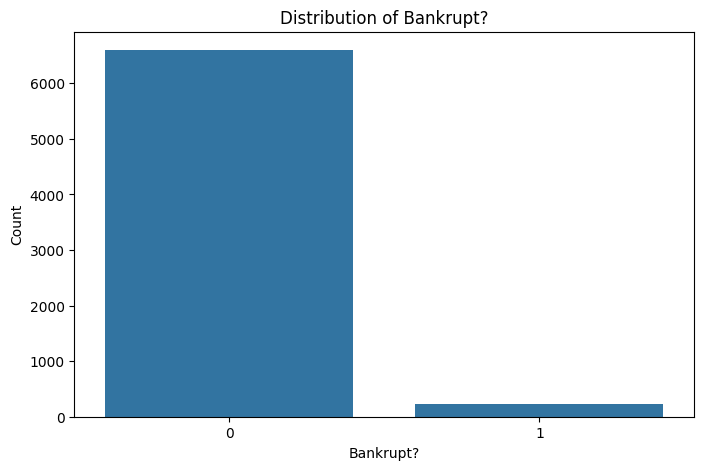

In [65]:
plt.figure(figsize=(8, 5))
sns.countplot(x=target_col, data=df_eda)
plt.title("Distribution of Bankrupt?")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.show()

**Interpretation:** This is descriptive EDA only. It is safe before the split because it does not use the target to select features or fit preprocessing.

### 3.2 Summarise the Remaining Feature Variables
**Goal:** Describe the remaining feature set after Section 2 cleaning, including variable types, missingness, and broad descriptive statistics.


In [66]:
feature_cols = [col for col in df_eda.columns if col != target_col]
numeric_feature_cols = df_eda[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_feature_cols = df_eda[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

pd.DataFrame({
    "rows": [df_eda.shape[0]],
    "total_features": [len(feature_cols)],
    "numeric_features": [len(numeric_feature_cols)],
    "categorical_features": [len(categorical_feature_cols)]
})

,rows,total_features,numeric_features,categorical_features
0,6819,86,86,0


In [67]:
feature_missing_summary = pd.DataFrame({
    "missing_count": df_eda[feature_cols].isnull().sum(),
    "missing_percent": df_eda[feature_cols].isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

feature_missing_summary.head(20)

,missing_count,missing_percent
Current Asset Turnover Rate,1234,18.096495
Fixed Assets Turnover Frequency,1228,18.008506
Interest-bearing debt interest rate,214,3.138290
Long-term Liability to Current Assets,109,1.598475
Inventory/Current Liability,99,1.451826
Cash/Current Liability,46,0.674586
Accounts Receivable Turnover,22,0.322628
Total assets to GNP price,20,0.293298
Average Collection Days,18,0.263968
Allocation rate per person,12,0.175979


In [68]:
df_eda[numeric_feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
Realized Sales Gross Margin,6819.0,0.607929,0.016916,0.0,0.600434,0.605976,0.613842,1.0
...,...,...,...,...,...,...,...,...
Net Income to Stockholder's Equity,6819.0,0.840402,0.014523,0.0,0.840115,0.841179,0.842357,1.0
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0


**Interpretation:** This subsection remains descriptive and does not remove or transform variables. Its purpose is to understand what remains after unsupervised cleaning.

### 3.3 Examine Distribution Shape and Skewness
**Goal:** Identify broad distributional patterns in the remaining numeric features, especially skewness and concentration, to inform later preprocessing choices.


In [69]:
skewness_summary = (
    df_eda[numeric_feature_cols]
    .skew()
    .sort_values(key=np.abs, ascending=False)
    .to_frame(name="skewness")
)

skewness_summary.head(20)

,skewness
Total income/Total expense,82.332424
Net Value Growth Rate,79.727581
Contingent liabilities/Net worth,79.670620
Realized Sales Gross Profit Growth Rate,77.925109
Operating Profit Growth Rate,-71.688950
Operating Profit Rate,-70.237164
Continuous Net Profit Growth Rate,67.097534
Total Asset Return Growth Rate Ratio,62.499961
Current Asset Turnover Rate,57.689185
Continuous interest rate (after tax),-53.200121


In [70]:
selected_dist_features = skewness_summary.head(6).index.tolist()
selected_dist_features

[' Total income/Total expense',
 ' Net Value Growth Rate',
 ' Contingent liabilities/Net worth',
 ' Realized Sales Gross Profit Growth Rate',
 ' Operating Profit Growth Rate',
 ' Operating Profit Rate']

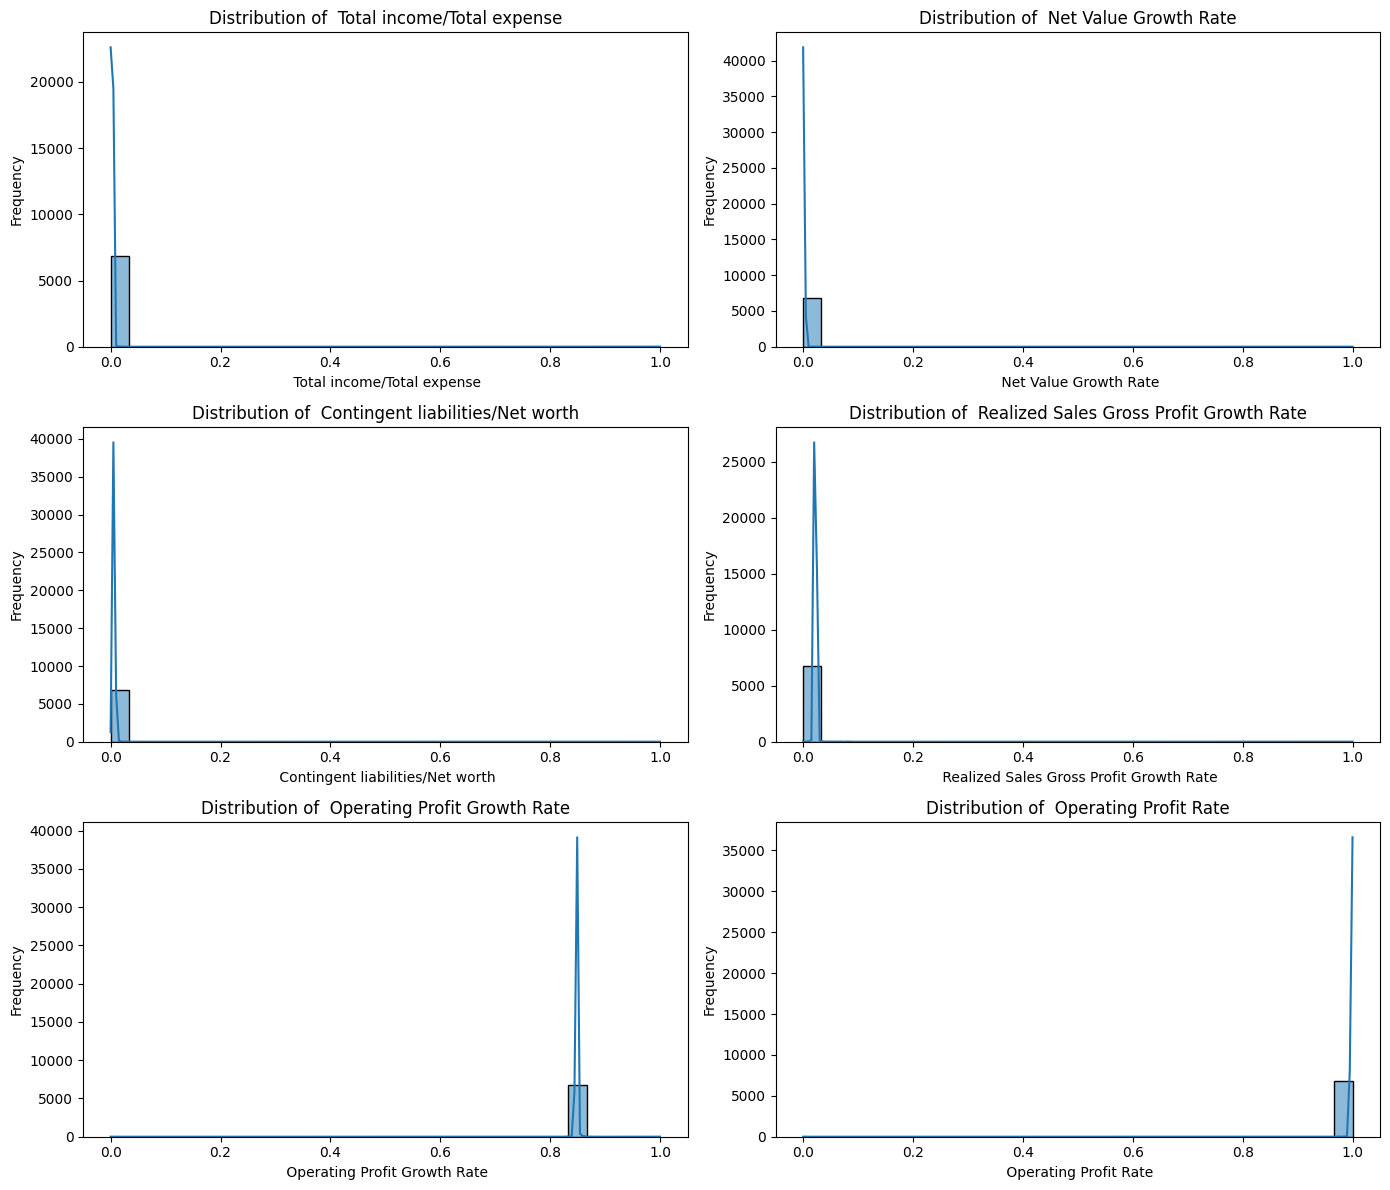

In [71]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, selected_dist_features):
    sns.histplot(df_eda[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(selected_dist_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Interpretation:** This analysis helps identify skewed variables, but no transformation is fitted here. Any later imputation, winsorisation, or scaling should still be learned from the training set only.

### 3.4 Check Outliers and Extreme Spread in Key Features
**Goal:** Inspect whether the remaining feature variables still contain strong outlier patterns that may matter for later robust preprocessing.

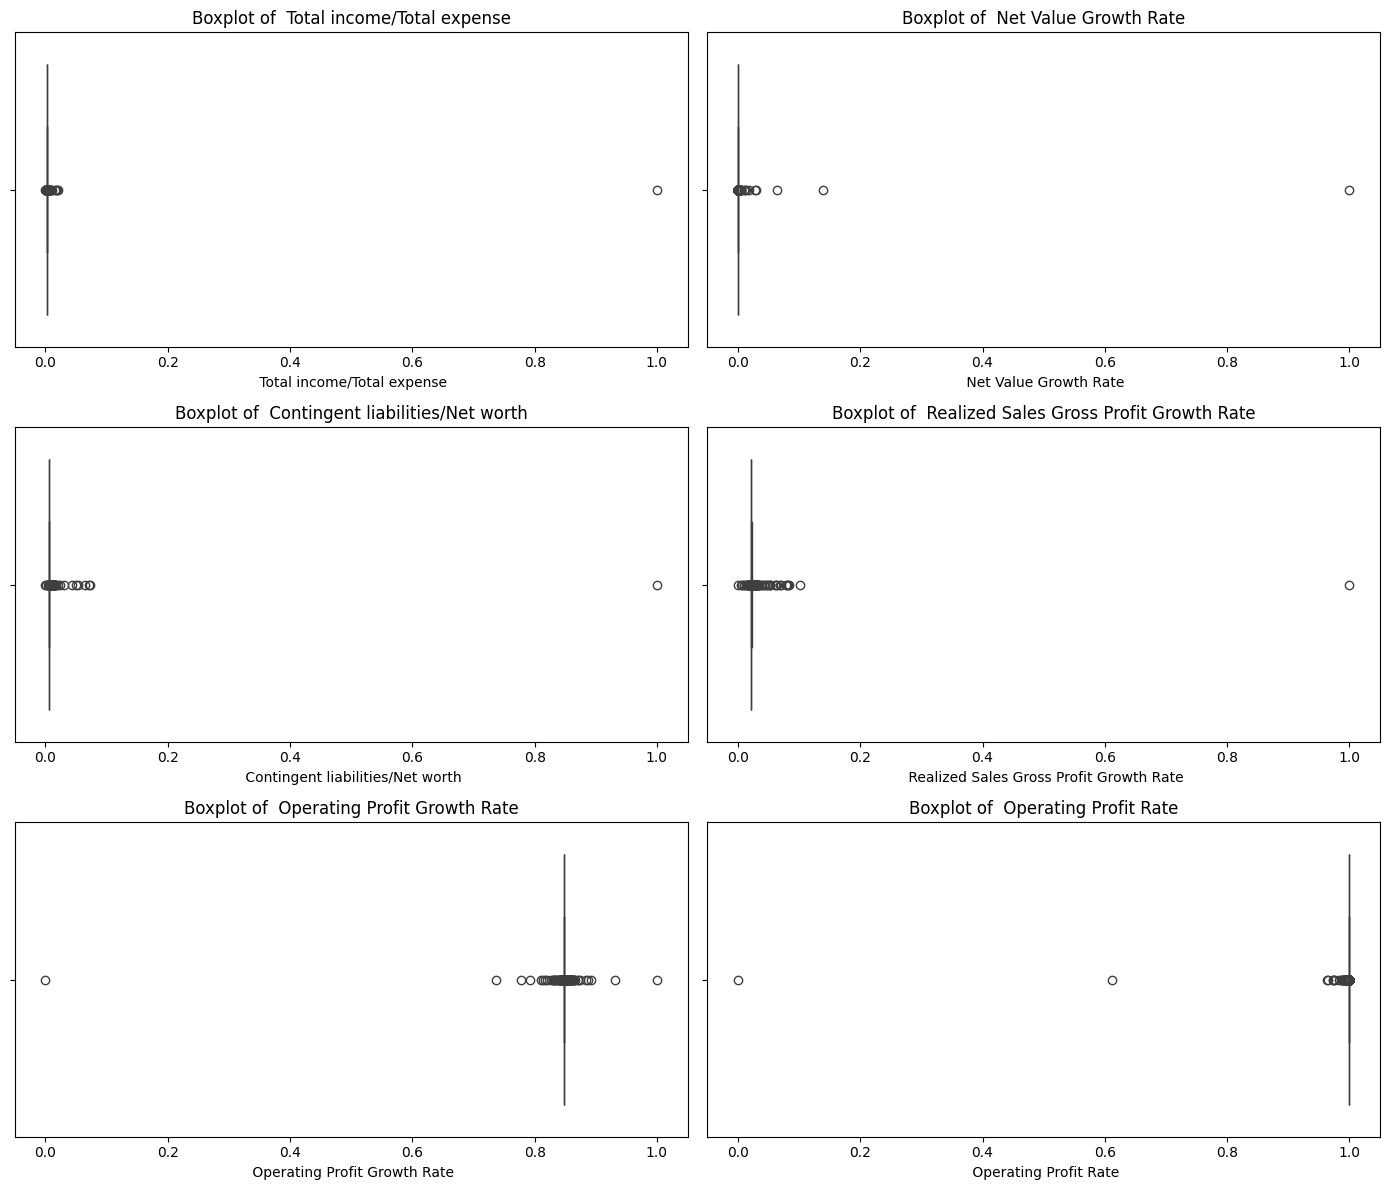

In [72]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, selected_dist_features):
    sns.boxplot(x=df_eda[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)

for ax in axes[len(selected_dist_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [73]:
outlier_summary = []

for col in numeric_feature_cols:
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df_eda[col] < lower_bound) | (df_eda[col] > upper_bound)).sum()

    outlier_summary.append({
        "feature": col,
        "outlier_count": int(outlier_count),
        "outlier_percent": outlier_count / len(df_eda) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    by="outlier_percent",
    ascending=False
)

outlier_summary.head(20)

,feature,outlier_count,outlier_percent
83,Degree of Financial Leverage (DFL),1503,22.041355
84,Interest Coverage Ratio (Interest expense to ...,1421,20.838833
31,Interest Expense Ratio,1362,19.973603
72,Cash Flow to Liability,1212,17.773867
79,No-credit Interval,1139,16.703329
8,Non-industry income and expenditure/revenue,1095,16.058073
66,Cash Flow to Sales,1052,15.427482
25,Continuous Net Profit Growth Rate,1042,15.280833
23,After-tax Net Profit Growth Rate,1033,15.148849
24,Regular Net Profit Growth Rate,1030,15.104854


**Interpretation:** This subsection is still descriptive. It helps justify robust preprocessing later, but it does not fit winsorisation thresholds or remove rows now.

### 3.5 Explore Correlation Structure Descriptively
**Goal:** Visualise the correlation structure of a small subset of important-looking numeric variables without making any feature-selection decisions yet.

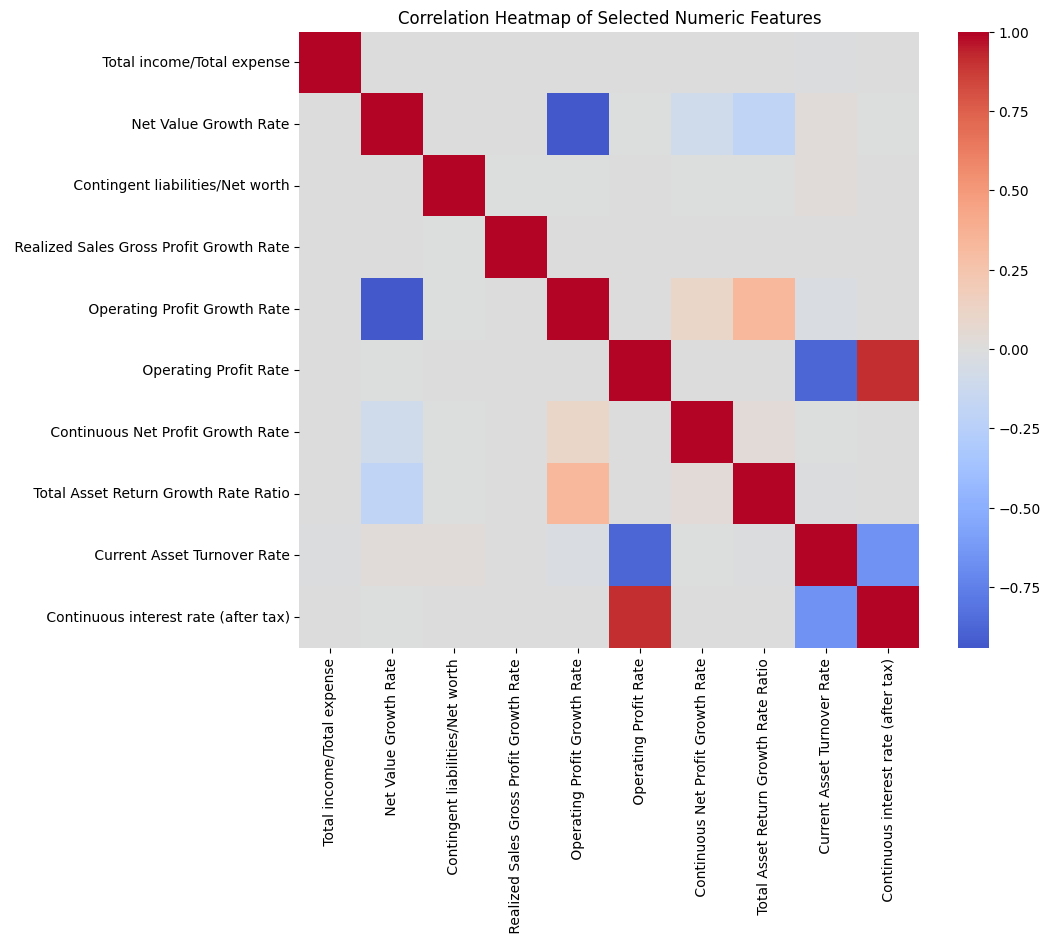

In [74]:
heatmap_features = skewness_summary.head(10).index.tolist()
corr_subset = df_eda[heatmap_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Selected Numeric Features")
plt.show()

**Interpretation:** The heatmap is included for descriptive understanding only. Correlation-based feature pruning should be delayed until after the train/validation/test split.

### 3.6 Summarise What Section 3 Does and Does Not Do
**Goal:** Make the role of Section 3 explicit so the later restructuring remains leakage-safe and easy to follow.


In [75]:
section3_scope = pd.DataFrame({
    "type": [
        "Descriptive target analysis",
        "Feature summary statistics",
        "Distribution plots",
        "Outlier review",
        "Correlation heatmap",
        "Feature selection using target",
        "Imputation",
        "Scaling or winsorisation"
    ],
    "included_in_section_3": [
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No",
        "No"
    ]
})

section3_scope

,type,included_in_section_3
0,Descriptive target analysis,Yes
1,Feature summary statistics,Yes
2,Distribution plots,Yes
3,Outlier review,Yes
4,Correlation heatmap,Yes
5,Feature selection using target,No
6,Imputation,No
7,Scaling or winsorisation,No


**Interpretation:** Section 3 is now purely descriptive EDA. This keeps the notebook close to the original structure while avoiding leakage from target-based screening or learned preprocessing before the split.

## Section 4: Train, Validation, and Test Split

### 4.1 Separate Features and Target
**Goal:** Separate the cleaned dataset `df_eda` into predictors and the target variable `Bankrupt?` so the split can happen before any modelling-driven preprocessing.


In [76]:
target_col = "Bankrupt?"

if "df_eda" not in globals():
    raise ValueError("df_eda is not available. Please run Section 2 first.")

if target_col not in df_eda.columns:
    raise ValueError(f"Target variable '{target_col}' is not present in df_eda.")

X = df_eda.drop(columns=[target_col]).copy()
y = df_eda[target_col].copy()

pd.DataFrame({
    "rows": [len(X)],
    "features": [X.shape[1]],
    "target_name": [target_col]
})

,rows,features,target_name
0,6819,86,Bankrupt?


### 4.2 Create Train, Validation, and Test Splits
**Goal:** Split the cleaned dataset into training, validation, and test sets before any modelling-oriented screening or preprocessing is fitted.


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()]
})

,dataset,rows,positive_rate
0,Train,4773,0.032265
1,Validation,1023,0.032258
2,Test,1023,0.032258


**Interpretation:** The split now happens before feature screening, imputation, scaling, or any other modelling-oriented step. This is the main structural change that reduces leakage.

### 4.3 Confirm That the Test Set Remains Untouched
**Goal:** Record the split objects clearly so later sections can use only the training set to fit screening and preprocessing while keeping the test set untouched.


In [78]:
split_summary = pd.DataFrame({
    "object_name": ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"],
    "shape_or_length": [
        X_train.shape,
        X_val.shape,
        X_test.shape,
        len(y_train),
        len(y_val),
        len(y_test)
    ]
})

split_summary

,object_name,shape_or_length
0,X_train,"(4773, 86)"
1,X_val,"(1023, 86)"
2,X_test,"(1023, 86)"
3,y_train,4773
4,y_val,1023
5,y_test,1023


**Interpretation:** From this point onward, any step that learns from the data for modelling must use `X_train` and, if needed, `y_train` only. Validation and test should only receive the fitted decisions.

## Section 5: Training-Only Feature Screening

### 5.1 Prepare Training-Only Screening Inputs
**Goal:** Set up the training data for feature screening and create logs so every screening decision is transparent and can later be applied consistently to validation and test.


In [79]:
screening_decisions = []

numeric_train_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_train_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pd.DataFrame({
    "rows_in_training_set": [len(X_train)],
    "numeric_features": [len(numeric_train_cols)],
    "categorical_features": [len(categorical_train_cols)]
})

,rows_in_training_set,numeric_features,categorical_features
0,4773,86,0


### 5.2 Remove Constant and Near-Zero Variance Features Using Training Data Only
**Goal:** Identify features with no variation or almost no variation in the training set and remove them before modelling.


In [80]:
constant_cols = [
    col for col in X_train.columns
    if X_train[col].nunique(dropna=False) <= 1
]

near_zero_variance_cols = []
for col in numeric_train_cols:
    value_freq = X_train[col].value_counts(dropna=False, normalize=True)
    if len(value_freq) > 1 and value_freq.iloc[0] >= 0.995 and col not in constant_cols:
        near_zero_variance_cols.append(col)

for col in constant_cols:
    screening_decisions.append({
        "feature": col,
        "decision": "Removed",
        "retained_feature": None,
        "reason": "Constant feature in the training set"
    })

for col in near_zero_variance_cols:
    screening_decisions.append({
        "feature": col,
        "decision": "Removed",
        "retained_feature": None,
        "reason": "Near-zero variance feature in the training set"
    })

variance_drop_cols = sorted(set(constant_cols + near_zero_variance_cols))

pd.DataFrame({
    "constant_features_removed": [constant_cols],
    "near_zero_variance_features_removed": [near_zero_variance_cols],
    "total_removed": [len(variance_drop_cols)]
})

,constant_features_removed,near_zero_variance_features_removed,total_removed
0,[],[ Liability-Assets Flag],1


**Interpretation:** These removals are now fitted on the training set only. The resulting drop list will be applied unchanged to validation and test.

### 5.3 Identify Highly Correlated Training Features
**Goal:** Detect strongly redundant numeric features in the training set using a high-correlation threshold and prepare a conservative retention rule.

In [81]:
numeric_after_variance = [
    col for col in X_train.select_dtypes(include=[np.number]).columns
    if col not in variance_drop_cols
]

corr_matrix = X_train[numeric_after_variance].corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] > 0.90].sort_values(
    by="abs_corr",
    ascending=False
).reset_index(drop=True)

high_corr_pairs.head(30)

,feature_1,feature_2,abs_corr
0,Current Liabilities/Equity,Current Liability to Equity,1.000000
1,Current Liabilities/Liability,Current Liability to Liability,1.000000
2,Debt ratio %,Net worth/Assets,1.000000
3,Operating Gross Margin,Gross Profit to Sales,1.000000
4,Pre-tax net Interest Rate,After-tax net Interest Rate,0.999882
5,Net Value Per Share (A),Net Value Per Share (C),0.999845
6,After-tax net Interest Rate,Continuous interest rate (after tax),0.999755
7,Net Value Per Share (B),Net Value Per Share (A),0.999744
8,Pre-tax net Interest Rate,Continuous interest rate (after tax),0.999600
9,Net Value Per Share (B),Net Value Per Share (C),0.999588


### 5.4 Retain One Feature per Highly Correlated Pair Using Training Data Only
**Goal:** Choose one representative feature from each highly correlated pair using interpretability and training-set target relevance, then remove the redundant alternative.


In [82]:
target_corr_train = (
    pd.concat([X_train[numeric_after_variance], y_train], axis=1)
    .corr()[target_col]
    .drop(labels=[target_col])
)

interpretability_priority = [
    "ROA", "ROE", "EPS", "Current Ratio", "Quick Ratio", "Debt ratio",
    "Liability to Equity", "Cash Flow", "Net Income", "Working Capital",
    "Retained Earnings", "Gross Profit", "Operating Profit", "Total Asset Turnover"
]

def interpretability_score(feature_name):
    score = 0
    for keyword in interpretability_priority:
        if keyword.lower() in str(feature_name).lower():
            score += 1
    return score

corr_drop_cols = set()
corr_retention_records = []

for _, row in high_corr_pairs.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]

    if f1 in corr_drop_cols or f2 in corr_drop_cols:
        continue

    score_1 = interpretability_score(f1)
    score_2 = interpretability_score(f2)

    target_1 = abs(target_corr_train.get(f1, 0))
    target_2 = abs(target_corr_train.get(f2, 0))

    if score_1 > score_2:
        keep_feature, drop_feature = f1, f2
        reason = "Retained because it is more interpretable or more common in financial analysis"
    elif score_2 > score_1:
        keep_feature, drop_feature = f2, f1
        reason = "Retained because it is more interpretable or more common in financial analysis"
    elif target_1 > target_2:
        keep_feature, drop_feature = f1, f2
        reason = "Retained because it has stronger absolute correlation with Bankrupt? in the training set"
    elif target_2 > target_1:
        keep_feature, drop_feature = f2, f1
        reason = "Retained because it has stronger absolute correlation with Bankrupt? in the training set"
    else:
        keep_feature, drop_feature = f1, f2
        reason = "Retained for consistency after ties on interpretability and training-set target correlation"

    corr_drop_cols.add(drop_feature)

    screening_decisions.append({
        "feature": drop_feature,
        "decision": "Removed",
        "retained_feature": keep_feature,
        "reason": f"Highly correlated with `{keep_feature}` in the training set (|corr| = {row['abs_corr']:.3f}); {reason}"
    })

    corr_retention_records.append({
        "retained_feature": keep_feature,
        "removed_feature": drop_feature,
        "abs_corr": row["abs_corr"],
        "reason": reason
    })

corr_retention_summary = pd.DataFrame(corr_retention_records)
corr_retention_summary.head(30)

,retained_feature,removed_feature,abs_corr,reason
0,Current Liability to Equity,Current Liabilities/Equity,1.000000,Retained because it is more interpretable or m...
1,Current Liabilities/Liability,Current Liability to Liability,1.000000,Retained for consistency after ties on interpr...
2,Debt ratio %,Net worth/Assets,1.000000,Retained because it is more interpretable or m...
3,Gross Profit to Sales,Operating Gross Margin,1.000000,Retained because it is more interpretable or m...
4,After-tax net Interest Rate,Pre-tax net Interest Rate,0.999882,Retained because it has stronger absolute corr...
5,Net Value Per Share (A),Net Value Per Share (C),0.999845,Retained because it has stronger absolute corr...
6,After-tax net Interest Rate,Continuous interest rate (after tax),0.999755,Retained because it has stronger absolute corr...
7,Net Value Per Share (A),Net Value Per Share (B),0.999744,Retained because it has stronger absolute corr...
8,Gross Profit to Sales,Realized Sales Gross Margin,0.999470,Retained because it is more interpretable or m...
9,Quick Ratio,Quick Assets/Current Liability,0.998212,Retained because it is more interpretable or m...


**Interpretation:** This is now leakage-safe because both the correlation structure and the target-based tie-break are derived from the training set only. No information from validation or test is used to choose the feature set.

### 5.5 Apply the Training-Derived Feature Set to Train, Validation, and Test
**Goal:** Apply the exact same feature-screening decisions from the training set to validation and test so all splits remain consistent.


In [83]:
screen_drop_cols = sorted(set(variance_drop_cols).union(corr_drop_cols))

X_train = X_train.drop(columns=screen_drop_cols, errors="ignore")
X_val = X_val.drop(columns=screen_drop_cols, errors="ignore")
X_test = X_test.drop(columns=screen_drop_cols, errors="ignore")

pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "features_after_screening": [X_train.shape[1], X_val.shape[1], X_test.shape[1]]
})

,dataset,rows,features_after_screening
0,Train,4773,59
1,Validation,1023,59
2,Test,1023,59


### 5.6 Record the Final Screening Decisions
**Goal:** Summarise which features were removed, which were retained, and why, so the screening process remains transparent and reproducible.


In [84]:
screening_report = pd.DataFrame(screening_decisions)
screening_report

,feature,decision,retained_feature,reason
0,Liability-Assets Flag,Removed,NaN,Near-zero variance feature in the training set
1,Current Liabilities/Equity,Removed,Current Liability to Equity,Highly correlated with ` Current Liability to ...
2,Current Liability to Liability,Removed,Current Liabilities/Liability,Highly correlated with ` Current Liabilities/L...
3,Net worth/Assets,Removed,Debt ratio %,Highly correlated with ` Debt ratio %` in the ...
4,Operating Gross Margin,Removed,Gross Profit to Sales,Highly correlated with ` Gross Profit to Sales...
5,Pre-tax net Interest Rate,Removed,After-tax net Interest Rate,Highly correlated with ` After-tax net Interes...
6,Net Value Per Share (C),Removed,Net Value Per Share (A),Highly correlated with ` Net Value Per Share (...
7,Continuous interest rate (after tax),Removed,After-tax net Interest Rate,Highly correlated with ` After-tax net Interes...
8,Net Value Per Share (B),Removed,Net Value Per Share (A),Highly correlated with ` Net Value Per Share (...
9,Realized Sales Gross Margin,Removed,Gross Profit to Sales,Highly correlated with ` Gross Profit to Sales...


In [85]:
pd.DataFrame({
    "original_feature_count_before_screening": [X.shape[1]],
    "final_feature_count_after_screening": [X_train.shape[1]],
    "removed_for_variance": [len(variance_drop_cols)],
    "removed_for_high_correlation": [len(corr_drop_cols)],
    "total_removed": [len(screen_drop_cols)]
})

,original_feature_count_before_screening,final_feature_count_after_screening,removed_for_variance,removed_for_high_correlation,total_removed
0,86,59,1,26,27


**Interpretation:** The feature set is now fixed using training-set information only. This keeps later preprocessing and modelling aligned across train, validation, and test.

### 5.7 Save the Screened Dataset
**Goal:** Save the screened version of the cleaned dataset to `data_2_screened.csv` using the training-derived retained feature set so the notebook preserves the original two-file logic.


In [86]:
df_screen = df_eda[X_train.columns.tolist() + [target_col]].copy()

screened_output_path = "data_2_screened.csv"
df_screen.to_csv(screened_output_path, index=False)

pd.DataFrame({
    "saved_file": [screened_output_path],
    "rows": [df_screen.shape[0]],
    "columns": [df_screen.shape[1]]
})

,saved_file,rows,columns
0,data_2_screened.csv,6819,60


**Interpretation:** `data_2_screened.csv` now reflects the feature set chosen from the training data only and then applied consistently to the rest of the dataset. This preserves the notebook’s two saved datasets while reducing leakage.

## Section 6: Post-Screening Descriptive EDA on the Training Set

### 6.1 Summarise the Screened Training Features
**Goal:** Review the screened training feature set so later preprocessing decisions are grounded in the actual features that will be used for modelling.


In [87]:
numeric_train_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_train_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pd.DataFrame({
    "rows_in_screened_training_set": [len(X_train)],
    "total_screened_features": [X_train.shape[1]],
    "numeric_features": [len(numeric_train_cols)],
    "categorical_features": [len(categorical_train_cols)]
})

,rows_in_screened_training_set,total_screened_features,numeric_features,categorical_features
0,4773,59,59,0


In [88]:
training_missing_summary = pd.DataFrame({
    "missing_count": X_train.isnull().sum(),
    "missing_percent": X_train.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

training_missing_summary.head(20)

,missing_count,missing_percent
Fixed Assets Turnover Frequency,869,18.206579
Interest-bearing debt interest rate,149,3.121726
Long-term Liability to Current Assets,77,1.613241
Inventory/Current Liability,71,1.487534
Cash/Current Liability,32,0.670438
Average Collection Days,15,0.314268
Accounts Receivable Turnover,15,0.314268
Total assets to GNP price,15,0.314268
Quick Ratio,7,0.146658
Allocation rate per person,7,0.146658


In [89]:
X_train[numeric_train_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Cash flow rate,4773.0,0.467208,0.015752,0.000000,0.461560,0.465081,0.470921,0.743251
Interest-bearing debt interest rate,4624.0,1081.315666,32869.123526,0.000000,0.000198,0.000313,0.000501,1000000.000000
Tax rate (A),4773.0,0.114470,0.139970,0.000000,0.000000,0.071363,0.203057,1.000000
Net Value Per Share (A),4773.0,0.189860,0.031099,0.000000,0.173528,0.184105,0.199275,0.549197
Persistent EPS in the Last Four Seasons,4773.0,0.228261,0.032254,0.078567,0.214617,0.224260,0.237875,1.000000
Cash Flow Per Share,4773.0,0.323575,0.017393,0.201988,0.317783,0.322452,0.328500,1.000000
Revenue Per Share (Yuan ¥),4771.0,0.038692,0.046270,0.000000,0.015571,0.027361,0.045828,1.000000
Realized Sales Gross Profit Growth Rate,4773.0,0.022228,0.002023,0.000000,0.022064,0.022102,0.022153,0.083455
Operating Profit Growth Rate,4773.0,0.847870,0.012401,0.000000,0.847982,0.848043,0.848122,0.887704
After-tax Net Profit Growth Rate,4773.0,0.689058,0.015261,0.000000,0.689268,0.689436,0.689643,1.000000


**Interpretation:** This section is descriptive only, but it is now correctly based on the screened training data rather than the full dataset.

### 6.2 Examine Distribution Shape and Skewness on the Training Set
**Goal:** Inspect skewness and broad distribution patterns in the screened training features to prepare for later preprocessing choices.


In [90]:
skewness_train = (
    X_train[numeric_train_cols]
    .skew()
    .sort_values(key=np.abs, ascending=False)
    .to_frame(name="skewness")
)

skewness_train.head(20)

,skewness
Total income/Total expense,68.964016
Operating Profit Growth Rate,-67.044791
Cash Flow to Sales,57.199758
Continuous Net Profit Growth Rate,-43.799867
Average Collection Days,41.852485
Degree of Financial Leverage (DFL),39.214631
Fixed Assets Turnover Frequency,38.571463
Equity to Long-term Liability,38.214809
Inventory/Current Liability,32.572187
Net Income to Stockholder's Equity,-31.139215


In [91]:
selected_train_dist_features = skewness_train.head(6).index.tolist()
selected_train_dist_features

[' Total income/Total expense',
 ' Operating Profit Growth Rate',
 ' Cash Flow to Sales',
 ' Continuous Net Profit Growth Rate',
 ' Average Collection Days',
 ' Degree of Financial Leverage (DFL)']

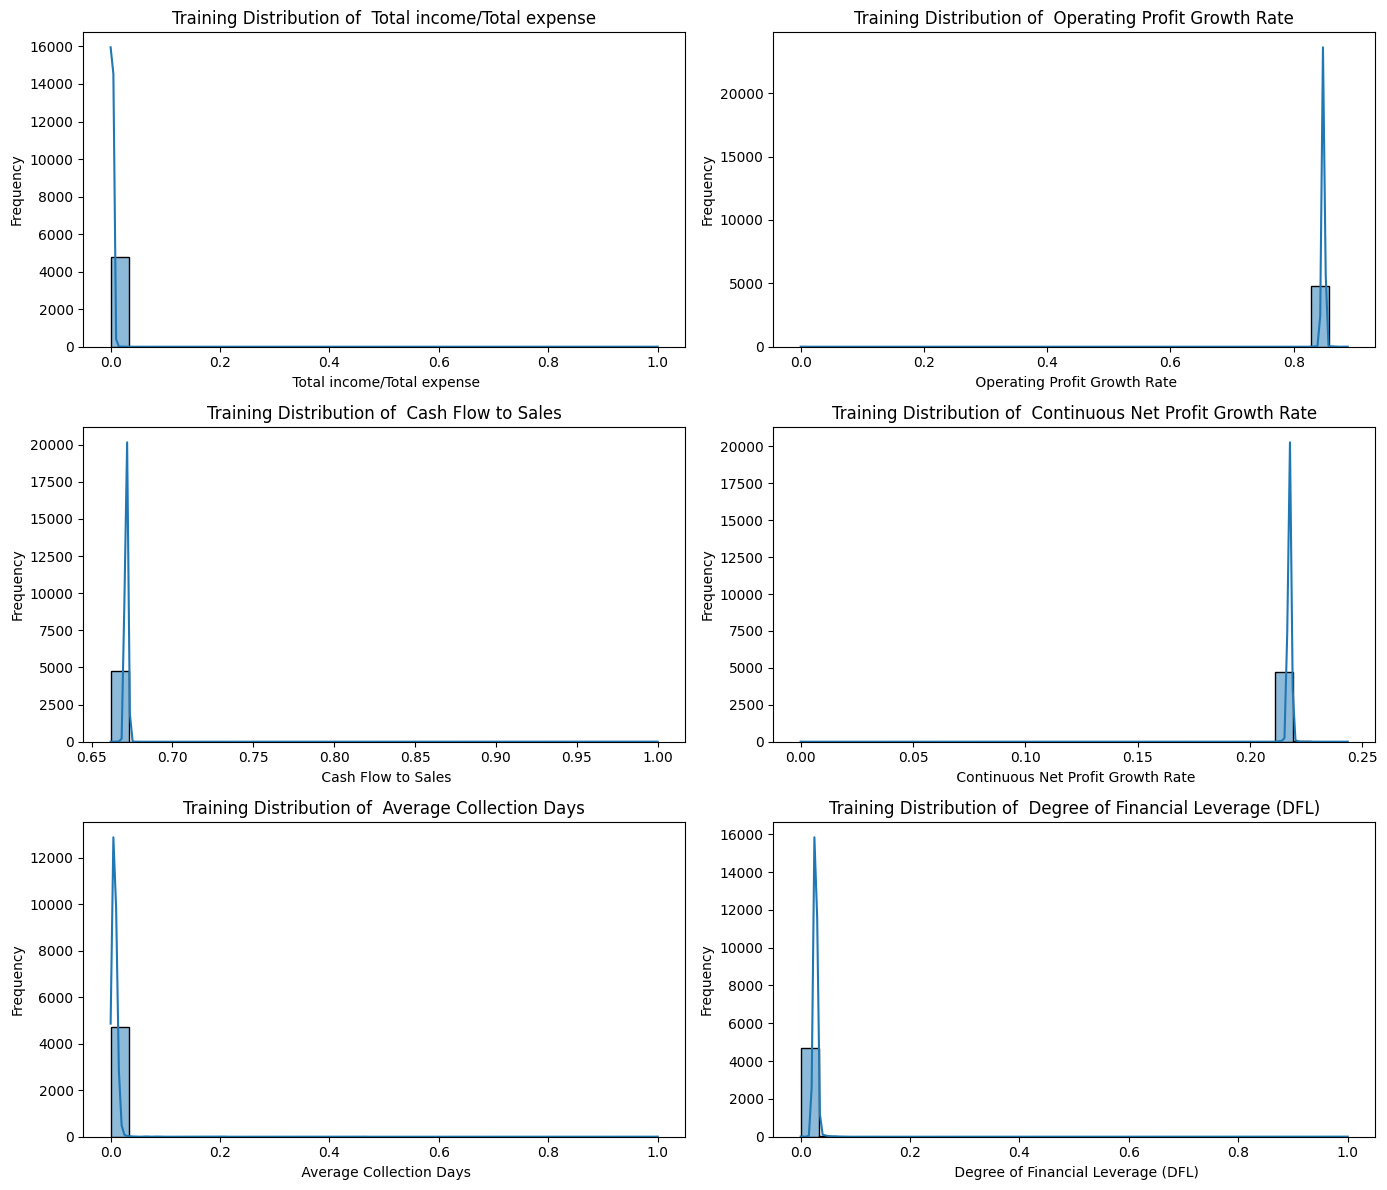

In [92]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, selected_train_dist_features):
    sns.histplot(X_train[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"Training Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(selected_train_dist_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Interpretation:** Skewness is now assessed in the correct place: after the split and after training-only feature screening. This supports later imputation and robust preprocessing decisions without leakage.

### 6.3 Review Outlier Patterns in the Screened Training Features
**Goal:** Inspect outlier behaviour in the screened training set so later winsorisation or robust preprocessing can be justified using training data only.


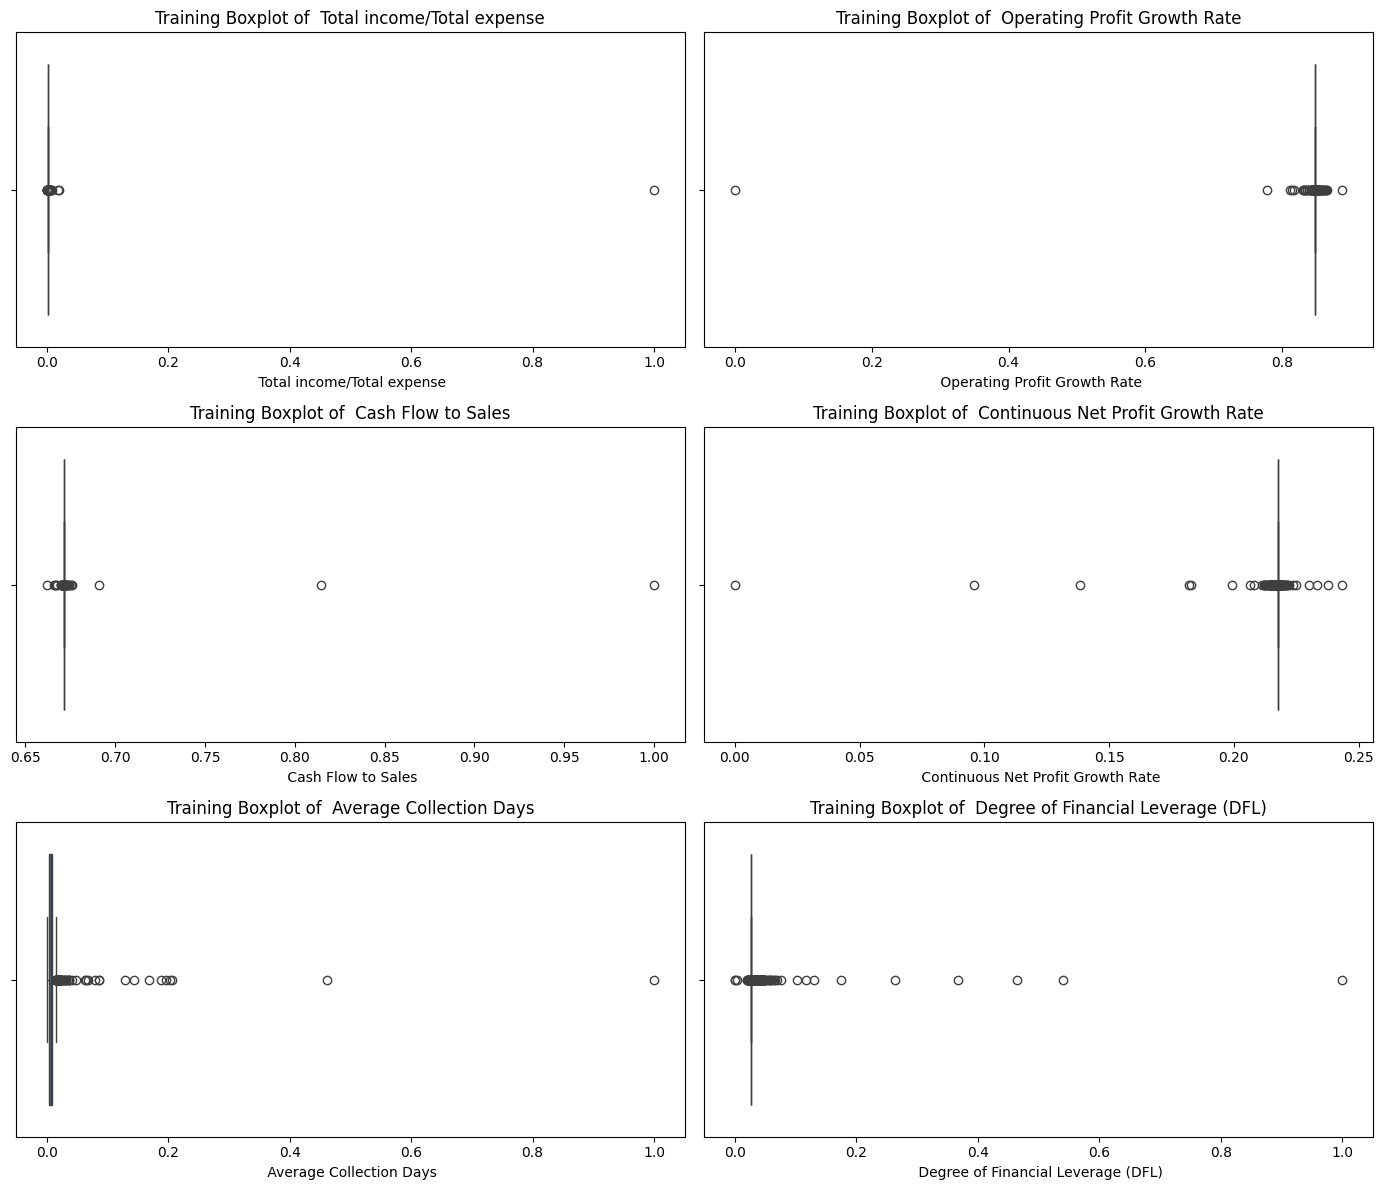

In [93]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, selected_train_dist_features):
    sns.boxplot(x=X_train[col], ax=ax)
    ax.set_title(f"Training Boxplot of {col}")
    ax.set_xlabel(col)

for ax in axes[len(selected_train_dist_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [94]:
outlier_summary_train = []

for col in numeric_train_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).sum()

    outlier_summary_train.append({
        "feature": col,
        "outlier_count": int(outlier_count),
        "outlier_percent": outlier_count / len(X_train) * 100
    })

outlier_summary_train = pd.DataFrame(outlier_summary_train).sort_values(
    by="outlier_percent",
    ascending=False
)

outlier_summary_train.head(20)

,feature,outlier_count,outlier_percent
56,Degree of Financial Leverage (DFL),1060,22.208255
57,Interest Coverage Ratio (Interest expense to ...,1003,21.014037
13,Interest Expense Ratio,961,20.134088
46,Cash Flow to Liability,838,17.557092
52,No-credit Interval,803,16.823801
10,Continuous Net Profit Growth Rate,746,15.629583
9,After-tax Net Profit Growth Rate,732,15.336266
42,Cash Flow to Sales,714,14.959145
8,Operating Profit Growth Rate,709,14.854389
34,Inventory/Working Capital,671,14.058244


**Interpretation:** This remains descriptive. It helps justify later winsorisation or robust scaling in Section 8, but no thresholds are learned yet.

### 6.4 Review Correlation Structure of the Screened Training Features
**Goal:** Visualise the remaining correlation structure in the screened training features after the major redundancy reduction from Section 5.

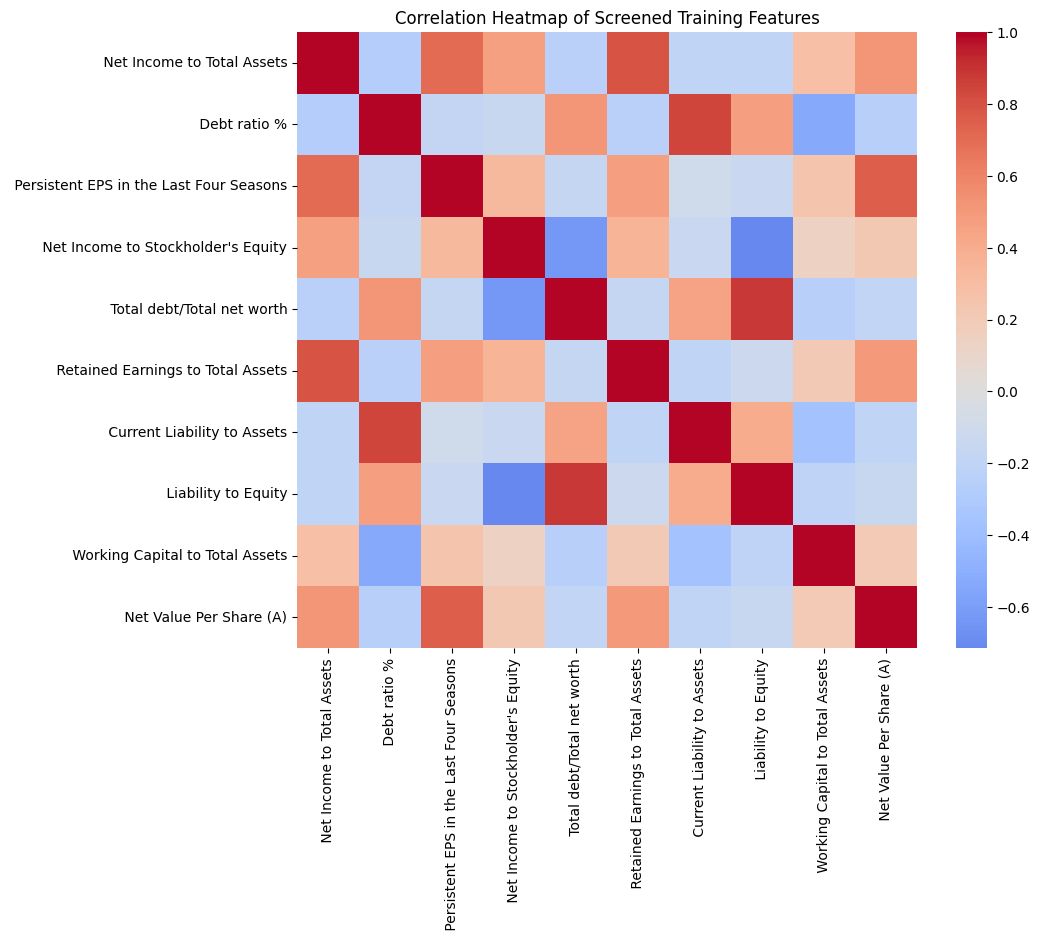

In [95]:
if "target_corr_train" in globals():
    heatmap_features = [
        col for col in target_corr_train.abs().sort_values(ascending=False).index.tolist()
        if col in X_train.columns
    ][:10]
else:
    heatmap_features = numeric_train_cols[:10]

corr_subset_train = X_train[heatmap_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset_train, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Screened Training Features")
plt.show()


**Interpretation:** This confirms whether substantial multicollinearity still remains after training-only screening and helps keep the workflow coherent before preprocessing begins.

## Section 7: Training-Only Diagnostics Before Preprocessing

### 7.1 Review Remaining Missingness in the Screened Training Features
**Goal:** Inspect the remaining missing-value pattern in the screened training features only, so the later imputation step is based on training data rather than the full dataset.


In [96]:
training_missing_summary = pd.DataFrame({
    "missing_count": X_train.isnull().sum(),
    "missing_percent": X_train.isnull().mean() * 100
}).sort_values(by="missing_percent", ascending=False)

training_missing_summary.head(30)

,missing_count,missing_percent
Fixed Assets Turnover Frequency,869,18.206579
Interest-bearing debt interest rate,149,3.121726
Long-term Liability to Current Assets,77,1.613241
Inventory/Current Liability,71,1.487534
Cash/Current Liability,32,0.670438
Average Collection Days,15,0.314268
Accounts Receivable Turnover,15,0.314268
Total assets to GNP price,15,0.314268
Quick Ratio,7,0.146658
Allocation rate per person,7,0.146658


In [97]:
row_missing_summary = pd.DataFrame({
    "missing_count_per_row": X_train.isnull().sum(axis=1),
    "missing_percent_per_row": X_train.isnull().mean(axis=1) * 100
})

row_missing_summary.describe()

,missing_count_per_row,missing_percent_per_row
count,4773.000000,4773.000000
mean,0.265032,0.449208
std,0.483537,0.819555
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,4.000000,6.779661


**Interpretation:** Missingness is now reviewed in the correct place: after the split and after training-only feature screening. This avoids leakage because the later imputation strategy will be informed only by the training data.

### 7.2 Confirm the Imputation Choice for Numeric Features
**Goal:** Assess the distributional shape of numeric training features with missing values and make a single justified choice between mean and median imputation.

In [98]:
# Summarise feature scale and spread
scale_profile = pd.DataFrame({
    "min": X_train[numeric_train_cols].min(),
    "median": X_train[numeric_train_cols].median(),
    "max": X_train[numeric_train_cols].max(),
    "std": X_train[numeric_train_cols].std(),
    "iqr": X_train[numeric_train_cols].quantile(0.75) - X_train[numeric_train_cols].quantile(0.25)
}).sort_values(by="std", ascending=False)

scale_profile.head(20)


,min,median,max,std,iqr
Interest-bearing debt interest rate,0.000000,0.000313,1000000.000000,32869.123526,0.000303
Current Assets/Total Assets,0.001407,0.514958,1.000000,0.219277,0.335985
Current Liabilities/Liability,0.000000,0.808014,1.000000,0.208091,0.317218
Quick Assets/Total Assets,0.001469,0.386745,1.000000,0.203073,0.300313
Fixed Assets to Assets,0.000000,0.201221,1.000000,0.200323,0.286589
Cash/Total Assets,0.000000,0.074171,1.000000,0.140672,0.125700
Tax rate (A),0.000000,0.071363,1.000000,0.139970,0.203057
Total Asset Turnover,0.000000,0.118441,1.000000,0.098722,0.101949
Working Capital to Total Assets,0.000000,0.810003,1.000000,0.059687,0.077384
CFO to Assets,0.000000,0.593339,1.000000,0.057896,0.058080


In [99]:
numeric_train_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_missing_cols = [
    col for col in numeric_train_cols
    if X_train[col].isnull().sum() > 0
]

skewness_for_missing_features = pd.DataFrame()

if len(numeric_missing_cols) > 0:
    skewness_for_missing_features = (
        X_train[numeric_missing_cols]
        .skew()
        .sort_values(key=np.abs, ascending=False)
        .to_frame(name="skewness")
    )

skewness_for_missing_features

,skewness
Average Collection Days,41.852485
Fixed Assets Turnover Frequency,38.571463
Inventory/Current Liability,32.572187
Interest-bearing debt interest rate,30.371030
Quick Ratio,28.123895
Accounts Receivable Turnover,24.024498
Long-term Liability to Current Assets,24.009509
Total debt/Total net worth,22.710068
Cash/Current Liability,12.781781
Total assets to GNP price,12.623253


In [100]:
imputation_decision_summary = pd.DataFrame({
    "numeric_features_with_missing_values": [len(numeric_missing_cols)],
    "chosen_numeric_imputation": ["median"]
})

imputation_decision_summary

,numeric_features_with_missing_values,chosen_numeric_imputation
0,13,median


**Interpretation:** Median imputation is chosen decisively because the remaining numeric features are financial ratios and related quantities that typically remain skewed and outlier-prone even after cleaning and feature screening. Median imputation is more robust than mean imputation under this distribution shape.

### 7.3 Check Scale Differences and Zero-Heavy Features in the Training Set
**Goal:** Review whether the screened training features still show large scale differences or zero-heavy patterns that justify robust preprocessing choices later.

In [101]:
scale_profile = pd.DataFrame({
    "min": X_train[numeric_train_cols].min(),
    "median": X_train[numeric_train_cols].median(),
    "max": X_train[numeric_train_cols].max(),
    "std": X_train[numeric_train_cols].std(),
    "iqr": X_train[numeric_train_cols].quantile(0.75) - X_train[numeric_train_cols].quantile(0.25)
}).sort_values(by="std", ascending=False)

scale_profile.head(20)

,min,median,max,std,iqr
Interest-bearing debt interest rate,0.000000,0.000313,1000000.000000,32869.123526,0.000303
Current Assets/Total Assets,0.001407,0.514958,1.000000,0.219277,0.335985
Current Liabilities/Liability,0.000000,0.808014,1.000000,0.208091,0.317218
Quick Assets/Total Assets,0.001469,0.386745,1.000000,0.203073,0.300313
Fixed Assets to Assets,0.000000,0.201221,1.000000,0.200323,0.286589
Cash/Total Assets,0.000000,0.074171,1.000000,0.140672,0.125700
Tax rate (A),0.000000,0.071363,1.000000,0.139970,0.203057
Total Asset Turnover,0.000000,0.118441,1.000000,0.098722,0.101949
Working Capital to Total Assets,0.000000,0.810003,1.000000,0.059687,0.077384
CFO to Assets,0.000000,0.593339,1.000000,0.057896,0.058080


In [102]:
zero_inflation_summary = pd.DataFrame({
    "zero_count": (X_train[numeric_train_cols] == 0).sum(),
    "zero_percent": (X_train[numeric_train_cols] == 0).mean() * 100,
    "nunique": X_train[numeric_train_cols].nunique()
}).sort_values(by="zero_percent", ascending=False)

zero_inflation_summary.head(20)

,zero_count,zero_percent,nunique
Tax rate (A),1810,37.921643,2020
Long-term Liability to Current Assets,1786,37.418814,2910
Interest-bearing debt interest rate,624,13.073539,916
Inventory/Current Liability,160,3.352189,4543
Fixed Assets to Assets,5,0.104756,4768
Fixed Assets Turnover Frequency,5,0.104756,1866
Allocation rate per person,5,0.104756,4738
Accounts Receivable Turnover,3,0.062854,1355
Total Asset Turnover,3,0.062854,350
Average Collection Days,3,0.062854,4063


**Interpretation:** These diagnostics help justify later winsorisation and scaling choices, but no transformation is fitted here yet. The role of Section 7 is still diagnostic rather than transformative.

### 7.4 Review Class-Conditional Separation for Key Training Features
**Goal:** Check whether the most relevant screened training features show meaningful separation between bankrupt and non-bankrupt firms before preprocessing and modelling.


In [103]:
top_train_target_features = []

if "target_corr_train" in globals():
    top_train_target_features = [
        col for col in target_corr_train.abs().sort_values(ascending=False).index.tolist()
        if col in X_train.columns
    ][:6]
else:
    temp_corr = (
        pd.concat([X_train[numeric_train_cols], y_train], axis=1)
        .corr()[target_col]
        .drop(labels=[target_col])
        .abs()
        .sort_values(ascending=False)
    )
    top_train_target_features = temp_corr.head(6).index.tolist()

top_train_target_features

[' Net Income to Total Assets',
 ' Debt ratio %',
 ' Persistent EPS in the Last Four Seasons',
 " Net Income to Stockholder's Equity",
 ' Total debt/Total net worth',
 ' Retained Earnings to Total Assets']

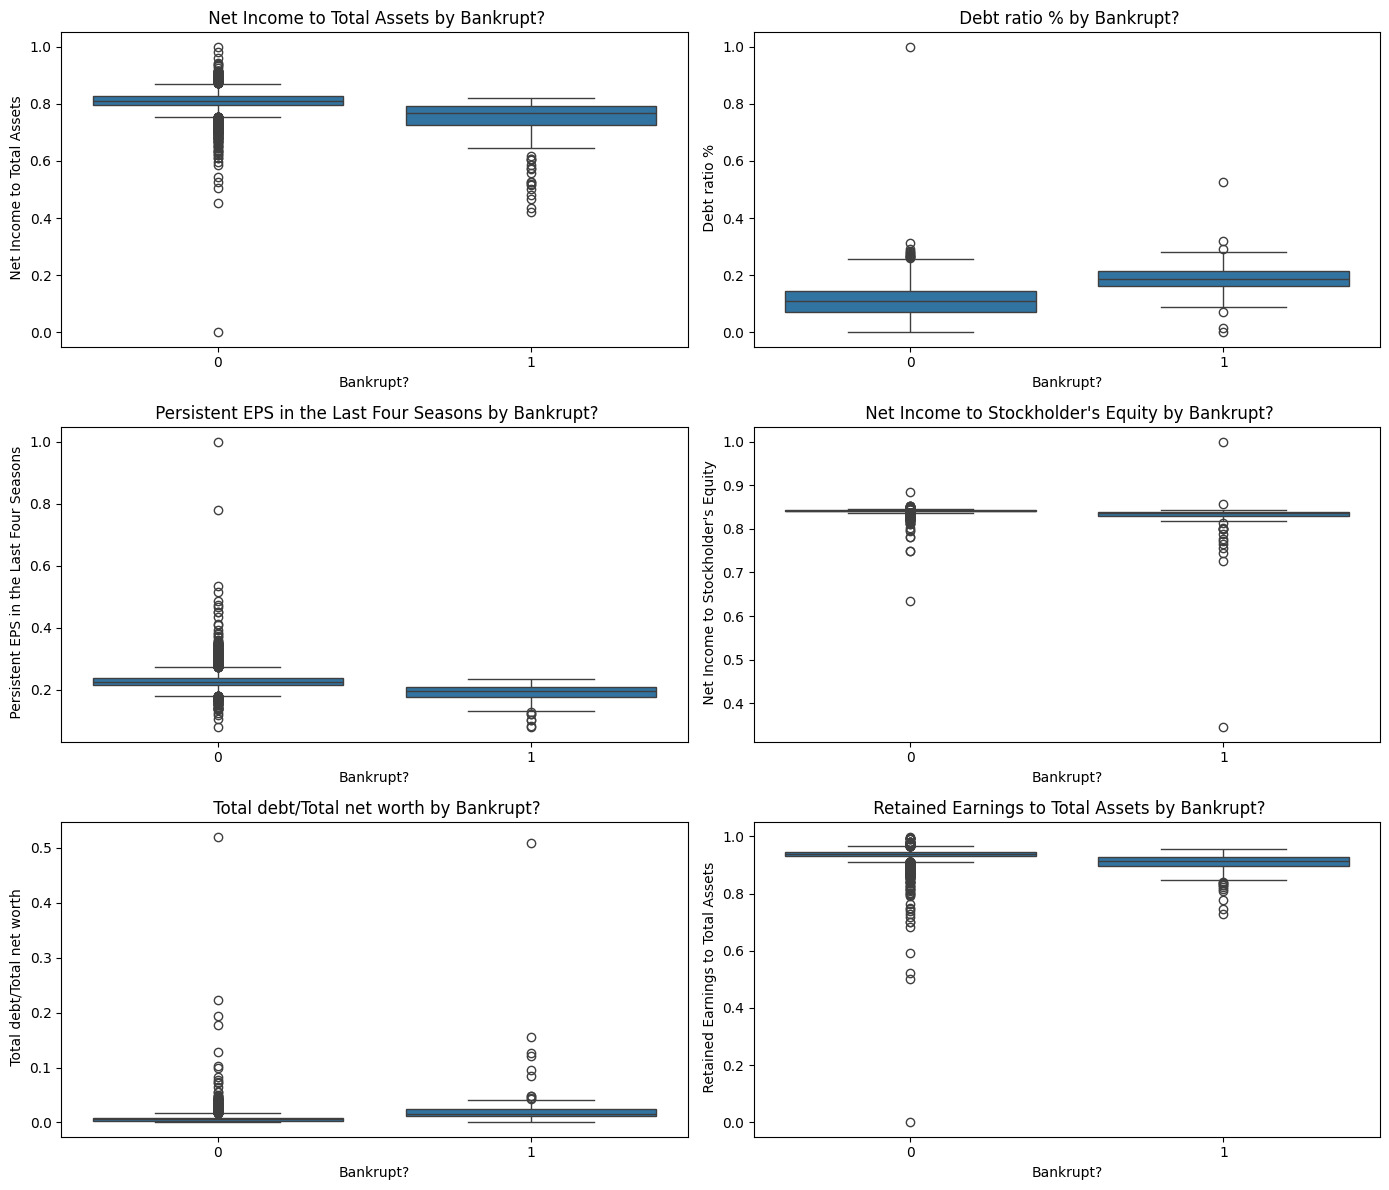

In [104]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for ax, col in zip(axes, top_train_target_features):
    sns.boxplot(data=pd.concat([X_train, y_train], axis=1), x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by {target_col}")

for ax in axes[len(top_train_target_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Interpretation:** This remains descriptive, but it is now focused on the screened training data, which is the correct reference point for the later modelling pipeline.

## Section 8: Training-Only Preprocessing for Modelling

### 8.1 Define the Preprocessing Inputs and Preserve Compatibility Objects
**Goal:** Prepare the screened train, validation, and test feature sets for leakage-safe preprocessing while preserving the existing object names needed by later sections.

In [105]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]]
})

,dataset,rows,features
0,Train,4773,59
1,Validation,1023,59
2,Test,1023,59


**Interpretation:** The screened objects `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, and `y_test` are deliberately preserved so later modelling sections remain compatible. Section 8 adds processed versions rather than overwriting the screened raw inputs.

### 8.2 Fit Missing-Value Imputation on the Training Set Only
**Goal:** Fit imputation on the training set only, using median imputation for numeric variables and most-frequent imputation for any categorical variables, then apply the fitted rules to validation and test.

In [106]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

if len(numeric_features) > 0:
    X_train_num = pd.DataFrame(
        numeric_imputer.fit_transform(X_train[numeric_features]),
        columns=numeric_features,
        index=X_train.index
    )
    X_val_num = pd.DataFrame(
        numeric_imputer.transform(X_val[numeric_features]),
        columns=numeric_features,
        index=X_val.index
    )
    X_test_num = pd.DataFrame(
        numeric_imputer.transform(X_test[numeric_features]),
        columns=numeric_features,
        index=X_test.index
    )
else:
    X_train_num = pd.DataFrame(index=X_train.index)
    X_val_num = pd.DataFrame(index=X_val.index)
    X_test_num = pd.DataFrame(index=X_test.index)

if len(categorical_features) > 0:
    X_train_cat = pd.DataFrame(
        categorical_imputer.fit_transform(X_train[categorical_features]),
        columns=categorical_features,
        index=X_train.index
    )
    X_val_cat = pd.DataFrame(
        categorical_imputer.transform(X_val[categorical_features]),
        columns=categorical_features,
        index=X_val.index
    )
    X_test_cat = pd.DataFrame(
        categorical_imputer.transform(X_test[categorical_features]),
        columns=categorical_features,
        index=X_test.index
    )
else:
    X_train_cat = pd.DataFrame(index=X_train.index)
    X_val_cat = pd.DataFrame(index=X_val.index)
    X_test_cat = pd.DataFrame(index=X_test.index)

**Interpretation:** This is the first point in the notebook where missing values are actually filled. The imputation rules are learned from the training set only and then applied unchanged to validation and test, which avoids leakage.

### 8.3 Fit Winsorisation Thresholds on the Training Set Only
**Goal:** Reduce the influence of extreme tails in the numeric screened features by learning clipping thresholds from the training set only and applying them consistently to validation and test.


In [107]:
if len(numeric_features) > 0:
    lower_quantiles = X_train_num.quantile(0.01)
    upper_quantiles = X_train_num.quantile(0.99)

    X_train_num = X_train_num.clip(lower=lower_quantiles, upper=upper_quantiles, axis=1)
    X_val_num = X_val_num.clip(lower=lower_quantiles, upper=upper_quantiles, axis=1)
    X_test_num = X_test_num.clip(lower=lower_quantiles, upper=upper_quantiles, axis=1)

    winsorisation_summary = pd.DataFrame({
        "feature": numeric_features,
        "lower_bound_1pct": lower_quantiles.values,
        "upper_bound_99pct": upper_quantiles.values
    })

    winsorisation_summary.head(20)
else:
    pd.DataFrame({"message": ["No numeric features available for winsorisation."]})

**Interpretation:** Winsorisation is fitted only on the training set because the clipping thresholds are learned from the training distribution. This is appropriate after the earlier diagnostics showed skewness and outlier-prone financial variables.

### 8.4 Fit Scaling on the Training Set Only
**Goal:** Standardise the numeric features using training-set parameters only and then apply the same scaling to validation and test.


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

if len(numeric_features) > 0:
    X_train_num = pd.DataFrame(
        scaler.fit_transform(X_train_num),
        columns=numeric_features,
        index=X_train.index
    )
    X_val_num = pd.DataFrame(
        scaler.transform(X_val_num),
        columns=numeric_features,
        index=X_val.index
    )
    X_test_num = pd.DataFrame(
        scaler.transform(X_test_num),
        columns=numeric_features,
        index=X_test.index
    )
else:
    X_train_num = pd.DataFrame(index=X_train.index)
    X_val_num = pd.DataFrame(index=X_val.index)
    X_test_num = pd.DataFrame(index=X_test.index)

**Interpretation:** Scaling is learned from the training set only. This maintains leakage-safe preprocessing and keeps the transformed feature space consistent across all splits.

### 8.5 Recombine the Processed Features and Create Final Modelling Objects
**Goal:** Recombine processed numeric and categorical features, align columns across train, validation, and test, and create the final modelling-ready objects expected by later sections.


In [109]:
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_processed = pd.concat([X_val_num, X_val_cat], axis=1)
X_test_processed = pd.concat([X_test_num, X_test_cat], axis=1)

final_feature_order = X_train_processed.columns.tolist()
X_val_processed = X_val_processed.reindex(columns=final_feature_order)
X_test_processed = X_test_processed.reindex(columns=final_feature_order)

X_train_final = X_train_processed.copy()
X_val_final = X_val_processed.copy()
X_test_final = X_test_processed.copy()

y_train_final = y_train.copy()
y_val_final = y_val.copy()
y_test_final = y_test.copy()

pd.DataFrame({
    "object_name": [
        "X_train_final", "X_val_final", "X_test_final",
        "y_train_final", "y_val_final", "y_test_final"
    ],
    "shape_or_length": [
        X_train_final.shape,
        X_val_final.shape,
        X_test_final.shape,
        len(y_train_final),
        len(y_val_final),
        len(y_test_final)
    ]
})

,object_name,shape_or_length
0,X_train_final,"(4773, 59)"
1,X_val_final,"(1023, 59)"
2,X_test_final,"(1023, 59)"
3,y_train_final,4773
4,y_val_final,1023
5,y_test_final,1023


**Interpretation:** These final objects are ready for modelling if you want to use a preprocessed design matrix directly. At the same time, the original screened `X_train`, `X_val`, and `X_test` are preserved so later sections that build their own pipelines remain compatible.

### 8.6 Verify That the Final Preprocessed Objects Are Clean
**Goal:** Confirm that the final processed train, validation, and test feature matrices have no remaining missing values and are ready for modelling.


In [110]:
preprocessing_check = pd.DataFrame({
    "dataset": ["Train", "Validation", "Test"],
    "missing_values": [
        X_train_final.isnull().sum().sum(),
        X_val_final.isnull().sum().sum(),
        X_test_final.isnull().sum().sum()
    ],
    "rows": [len(X_train_final), len(X_val_final), len(X_test_final)],
    "features": [
        X_train_final.shape[1],
        X_val_final.shape[1],
        X_test_final.shape[1]
    ]
})

preprocessing_check

,dataset,missing_values,rows,features
0,Train,0,4773,59
1,Validation,0,1023,59
2,Test,0,1023,59


In [111]:
X_train_final.head()

,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (A),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Continuous Net Profit Growth Rate,Cash Reinvestment %,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Long-term fund suitability ratio (A),Contingent liabilities/Net worth,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Cash Flow to Sales,Fixed Assets to Assets,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
3295,-0.170597,0.792750,-0.366257,-0.911652,-0.274529,-0.212847,-0.717912,1.067825,0.329124,0.227641,0.243634,0.197754,-0.600636,0.586243,-0.286953,-0.050552,-0.382062,-0.477047,-0.570930,-0.670018,-0.337486,0.269291,-0.283073,-0.545856,-0.624844,-0.226036,-0.216016,-1.145279,-0.816734,-1.216817,-0.848772,-0.560703,-0.158878,-0.166775,-2.352659,-0.864762,-0.283200,-1.099723,0.528349,-0.502396,-0.076828,-0.481690,-0.096646,1.134857,0.136336,-0.167635,-0.139220,0.024007,-0.152026,1.032477,0.055227,-0.364539,0.144654,0.294975,0.106748,-0.284169,0.186974,0.698015,-0.323935
2232,-0.133792,0.532273,-0.854911,-0.056640,-0.288979,1.528789,-0.490462,-0.436075,-0.277491,-0.046800,-0.071305,2.437214,-0.967768,2.938092,1.522450,1.540142,-0.262173,-0.477047,2.777467,-1.042996,1.104864,-1.452154,-0.314113,-0.527578,5.265355,4.057594,6.450108,-0.304393,-1.751638,1.186892,-0.760659,-0.557742,2.060085,-0.014150,1.654974,1.500918,0.872651,0.376961,-0.459266,0.178639,-0.073353,-1.029601,0.101014,-0.797173,-0.253127,-0.050471,-0.104152,0.893796,0.055225,0.399934,-0.216078,1.319810,-2.780631,-0.603853,-0.031389,1.543876,0.903536,1.363549,-0.771567
5538,0.494471,-0.592512,0.604914,0.701839,0.039759,0.111663,-0.544982,-0.115185,0.019203,0.061249,0.143334,0.137616,0.216972,-0.001556,-0.514862,-0.447789,-0.345244,0.414569,-0.619335,-0.832183,-0.352790,0.359168,-0.283073,-0.698178,-0.511976,-0.053580,0.142913,-0.136573,-0.882921,-1.012810,-0.601541,-0.252174,-1.224293,-0.055526,-0.146526,0.760299,-2.151903,-0.185838,1.214113,0.036368,0.038381,-0.703757,0.070154,0.674925,0.714501,-0.035682,-0.058153,0.081651,-0.032748,-0.773579,0.020422,-0.229013,0.957260,0.328533,0.046357,-0.514412,-0.135557,0.050285,-0.090164
6282,0.343918,0.144519,4.069985,0.058281,-0.462379,0.486784,-0.372478,-0.318293,-0.165772,-0.148115,-0.176432,0.877567,-0.568214,2.205142,-0.561330,-0.539369,-0.347606,0.503509,-0.598905,-0.426771,-0.285837,0.003860,-0.356886,-0.466649,-0.547683,-0.289334,-0.334033,-0.983461,-0.952459,-1.063017,-0.504622,-0.416175,-0.161376,0.530877,1.215345,-0.377726,0.701724,-0.952860,-0.565783,0.131976,-0.517786,-0.657367,-0.148193,0.309990,-0.674078,-0.239181,-0.186056,0.850743,-0.214802,0.725768,-0.343767,-0.322443,-0.667852,-0.589357,-0.230213,-0.561300,0.274063,0.817959,-0.020832
2143,-1.715808,-1.119385,-0.854911,-0.681810,-0.386517,-0.748735,-0.783506,0.211225,-0.286495,0.007870,-0.096327,-0.691

**Interpretation:** This verifies that the final modelling-ready matrices have been created correctly. No new dataset file is saved here, because `data_2_filtered.csv` and `data_2_screened.csv` already preserve the intended unsupervised-cleaned and screened dataset stages.

## Section 9: Baseline Binary Classification Model

### 9.1 Prepare the Training and Validation Data Only
**Goal:** Use only the training and validation sets for baseline modelling and confirm that the test set remains completely untouched.


In [112]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

required_objects = ["X_train", "X_val", "y_train", "y_val"]
missing_objects = [obj for obj in required_objects if obj not in globals()]

if missing_objects:
    raise ValueError(f"Missing required objects from the preprocessing stage: {missing_objects}")

X_train_baseline = X_train.copy()
X_val_baseline = X_val.copy()
y_train_baseline = y_train.copy()
y_val_baseline = y_val.copy()

numeric_features = X_train_baseline.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_baseline.select_dtypes(exclude=[np.number]).columns.tolist()

pd.DataFrame({
    "dataset": ["Train", "Validation"],
    "rows": [len(X_train_baseline), len(X_val_baseline)],
    "target_mean": [y_train_baseline.mean(), y_val_baseline.mean()]
})

,dataset,rows,target_mean
0,Train,4773,0.032265
1,Validation,1023,0.032258


**Interpretation:** This subsection keeps the modelling stage leakage-safe by using only the training and validation sets. The test set is intentionally excluded from all fitting, tuning, and evaluation.

### 9.2 Fit the Preprocessing Pipeline on the Training Set Only

**Goal:** Build a preprocessing pipeline that learns all imputation and scaling parameters from the training set only, then applies the same learned transformations to the validation set.



In [113]:
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features)
    ],
    remainder="drop"
)

X_train_prepared = preprocessor.fit_transform(X_train_baseline)
X_val_prepared = preprocessor.transform(X_val_baseline)

pd.DataFrame({
    "dataset": ["Train", "Validation"],
    "rows": [X_train_prepared.shape[0], X_val_prepared.shape[0]],
    "columns_after_preprocessing": [X_train_prepared.shape[1], X_val_prepared.shape[1]]
})


,dataset,rows,columns_after_preprocessing
0,Train,4773,59
1,Validation,1023,59


**Interpretation:** Every learned preprocessing step is fitted on the training data only. The validation set is transformed with the training-set parameters, which preserves strict anti-leakage practice.

### 9.3 Train a Baseline Classification Model
**Goal:** Train a simple but defensible baseline binary classifier that accounts for class imbalance and can serve as a benchmark for later models.

In [114]:
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train_prepared, y_train_baseline)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

**Interpretation:** Logistic regression with class_weight="balanced" is a reasonable baseline for an imbalanced bankruptcy task because it is simple, interpretable, and less likely to ignore the minority class than an unweighted baseline.

### 9.4 Evaluate the Baseline Model on the Validation Set
**Goal:** Evaluate the baseline model using imbalance-aware metrics that are more informative than plain accuracy for bankruptcy prediction.

In [115]:
y_val_pred = baseline_model.predict(X_val_prepared)
y_val_proba = baseline_model.predict_proba(X_val_prepared)[:, 1]

validation_metrics = pd.DataFrame({
    "metric": [
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "value": [
        balanced_accuracy_score(y_val_baseline, y_val_pred),
        precision_score(y_val_baseline, y_val_pred, zero_division=0),
        recall_score(y_val_baseline, y_val_pred, zero_division=0),
        f1_score(y_val_baseline, y_val_pred, zero_division=0),
        roc_auc_score(y_val_baseline, y_val_proba),
        average_precision_score(y_val_baseline, y_val_proba)
    ]
})

validation_metrics


,metric,value
0,Balanced Accuracy,0.847475
1,Precision,0.181208
2,Recall,0.818182
3,F1 Score,0.296703
4,ROC-AUC,0.891429
5,Average Precision,0.317469


In [116]:
conf_matrix = pd.DataFrame(
    confusion_matrix(y_val_baseline, y_val_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

conf_matrix


,Predicted 0,Predicted 1
Actual 0,868,122
Actual 1,6,27


In [117]:
classification_report_df = pd.DataFrame(
    classification_report(y_val_baseline, y_val_pred, output_dict=True, zero_division=0)
).T

classification_report_df


,precision,recall,f1-score,support
0,0.993135,0.876768,0.931330,990.000000
1,0.181208,0.818182,0.296703,33.000000
accuracy,0.874878,0.874878,0.874878,0.874878
macro avg,0.587172,0.847475,0.614017,1023.000000
weighted avg,0.966944,0.874878,0.910859,1023.000000


**Interpretation:** Balanced accuracy, recall, F1, ROC-AUC, and average precision are more appropriate than standard accuracy here because the bankruptcy class is likely to be the minority class. These metrics show whether the baseline model is learning useful minority-class signal rather than just predicting the majority class.

### 9.5 Visualise Baseline Validation Performance
**Goal:** Add simple validation-set visualisations to make the baseline model’s discrimination and class-imbalance behaviour easier to interpret.

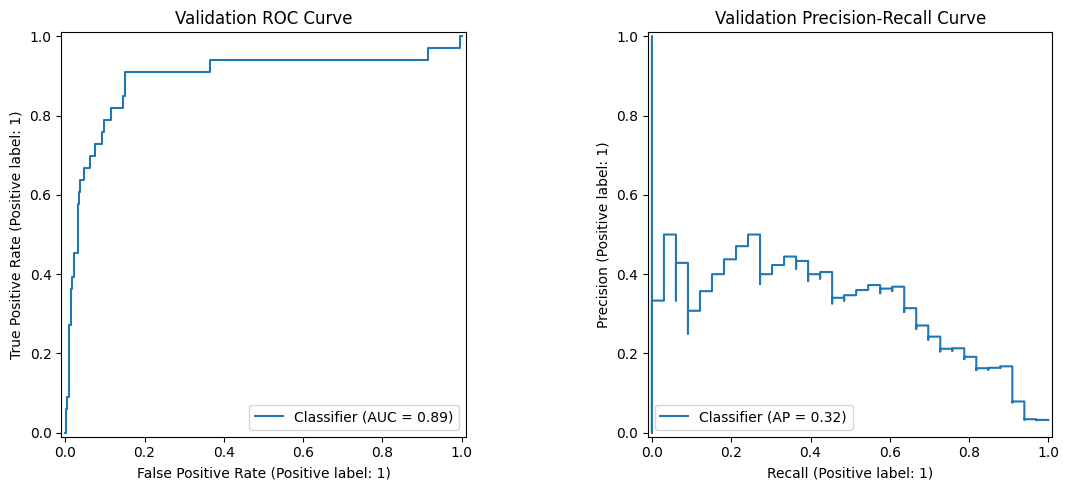

In [118]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_val_baseline,
    y_val_proba,
    ax=axes[0]
)
axes[0].set_title("Validation ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_val_baseline,
    y_val_proba,
    ax=axes[1]
)
axes[1].set_title("Validation Precision-Recall Curve")

plt.tight_layout()
plt.show()


**Interpretation:** The precision-recall curve is especially important in an imbalanced bankruptcy setting because it focuses attention on minority-class detection performance. The test set remains untouched and should only be used after model selection is complete.

### 9.6 Summarise the Baseline Modelling Stage
**Goal:** Record the main modelling choices and confirm that the baseline results are based only on training and validation data.

In [119]:
baseline_summary = pd.DataFrame({
    "item": [
        "Model",
        "Training data used",
        "Validation data used",
        "Test data used",
        "Imbalance handling",
        "Preprocessing fit on"
    ],
    "value": [
        "Logistic Regression",
        "Yes",
        "Yes",
        "No",
        "class_weight='balanced'",
        "Training set only"
    ]
})

baseline_summary


,item,value
0,Model,Logistic Regression
1,Training data used,Yes
2,Validation data used,Yes
3,Test data used,No
4,Imbalance handling,class_weight='balanced'
5,Preprocessing fit on,Training set only


**Interpretation:** This baseline gives you a clean, leakage-safe benchmark for later comparison. The test set has not been used at any point in preprocessing, fitting, or evaluation, so it remains available for final unbiased assessment later.

## Section 10: Recommended Modern Models

### 10.1 Modern Model Recommendation

#### Model Recommendation 1: LightGBM
**Goal:** Recommend a strong modern baseline model for imbalanced tabular financial data.

LightGBM is one of the best choices for this project because it is designed for structured tabular datasets and usually performs very well on financial-ratio classification problems. It handles non-linear relationships and feature interactions better than a simple linear model, trains efficiently, and can work well even when many features are correlated or differently scaled.

It is also suitable for class-imbalanced bankruptcy prediction because it supports imbalance-aware settings such as class weights or `scale_pos_weight`, and it often achieves strong ranking performance on metrics such as ROC-AUC and average precision.

**Interpretation:** LightGBM is a very practical first modern model here because it is strong on tabular data, efficient to tune, and well suited to imbalanced binary classification.

#### Model Recommendation 2: XGBoost
**Goal:** Recommend a second strong modern model that is robust, widely used, and highly competitive on tabular prediction tasks.

XGBoost is another very suitable choice for this dataset because it is a high-performing gradient boosting method that works especially well on medium-sized structured datasets with complex non-linear patterns. Bankruptcy risk from financial ratios is unlikely to be purely linear, so XGBoost is a strong candidate for capturing more subtle interactions among profitability, leverage, liquidity, and turnover variables.

It is also widely used in credit risk and financial distress modelling, which makes it a methodologically defensible choice for your research question. Like LightGBM, it supports class weighting and imbalance-aware training.

**Interpretation:** XGBoost is a strong second choice because it is reliable, widely accepted in financial prediction tasks, and often performs very competitively on imbalanced tabular data.

#### Why These Two Are Better Priorities Than the Other Options
**Goal:** Briefly explain why these two models should be prioritised over other possible models for this project.

Random Forest is a reasonable benchmark, but it is usually less competitive than modern boosting methods on tabular classification problems like this one. CatBoost is also strong, but its main advantage is often larger when categorical variables are important, whereas your dataset is mainly numeric financial ratios. A simple feed-forward DNN is usually not the best first choice here because tabular financial datasets of this size are more often won by gradient boosting methods than by neural networks.

**Interpretation:** If you want only the top 2 modern models to prioritise, LightGBM and XGBoost are the most defensible and practical pair for this bankruptcy prediction task.




### 10.2 Prepare the Training and Validation Data
**Goal:** Use only the training and validation sets, keep the test set untouched, and define the feature types needed for leakage-safe preprocessing.

In [120]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

required_objects = ["X_train", "X_val", "y_train", "y_val"]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise ValueError(f"Missing required objects: {missing_objects}")

X_train_model = X_train.copy()
X_val_model = X_val.copy()
y_train_model = y_train.copy()
y_val_model = y_val.copy()

numeric_features = X_train_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_model.select_dtypes(exclude=[np.number]).columns.tolist()

pd.DataFrame({
    "dataset": ["Train", "Validation"],
    "rows": [len(X_train_model), len(X_val_model)],
    "positive_rate": [y_train_model.mean(), y_val_model.mean()]
})

,dataset,rows,positive_rate
0,Train,4773,0.032265
1,Validation,1023,0.032258


**Interpretation:** This keeps the test set completely unused and confirms that all modelling decisions are based only on the training and validation data.

### 10.3 Fit Preprocessing on the Training Set Only
**Goal:** Apply the correct anti-leakage preprocessing order by fitting all preprocessing steps on the training set only and then applying them to the validation set.

In [121]:
numeric_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features)
    ],
    remainder="drop"
)

X_train_prepared = preprocessor.fit_transform(X_train_model)
X_val_prepared = preprocessor.transform(X_val_model)

train_pos = y_train_model.sum()
train_neg = len(y_train_model) - train_pos
scale_pos_weight = train_neg / train_pos

pd.DataFrame({
    "item": ["Train rows", "Validation rows", "Features after preprocessing", "scale_pos_weight"],
    "value": [X_train_prepared.shape[0], X_val_prepared.shape[0], X_train_prepared.shape[1], scale_pos_weight]
})


,item,value
0,Train rows,4773.000000
1,Validation rows,1023.000000
2,Features after preprocessing,59.000000
3,scale_pos_weight,29.993506


**Interpretation:** Median and most-frequent imputation are fitted only on the training set. No preprocessing step is learned from the validation set.

### 10.4 Train LightGBM on the Training Set
**Goal:** Train a modern gradient boosting model that is well suited to imbalanced tabular financial data.

In [122]:
lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

lgbm_model.fit(X_train_prepared, y_train_model)

lgbm_val_pred = lgbm_model.predict(X_val_prepared)
lgbm_val_proba = lgbm_model.predict_proba(X_val_prepared)[:, 1]


[LightGBM] [Info] Number of positive: 154, number of negative: 4619
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15045
[LightGBM] [Info] Number of data points in the train set: 4773, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**Interpretation:** LightGBM is a strong first modern model here because it handles non-linearity, interactions, and class imbalance well on tabular data.

### 10.5 Train XGBoost on the Training Set
**Goal:** Train a second strong modern boosting model for direct validation-based comparison.

In [123]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_prepared, y_train_model)

xgb_val_pred = xgb_model.predict(X_val_prepared)
xgb_val_proba = xgb_model.predict_proba(X_val_prepared)[:, 1]


**Interpretation:** XGBoost is included because it is widely used, robust, and highly competitive on structured financial classification tasks.

### 10.6 Compare Validation Performance
**Goal:** Evaluate both models with imbalance-aware validation metrics and compare them clearly without using the test set.

In [124]:
model_results = pd.DataFrame([
    {
        "model": "LightGBM",
        "balanced_accuracy": balanced_accuracy_score(y_val_model, lgbm_val_pred),
        "precision": precision_score(y_val_model, lgbm_val_pred, zero_division=0),
        "recall": recall_score(y_val_model, lgbm_val_pred, zero_division=0),
        "f1": f1_score(y_val_model, lgbm_val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val_model, lgbm_val_proba),
        "average_precision": average_precision_score(y_val_model, lgbm_val_proba)
    },
    {
        "model": "XGBoost",
        "balanced_accuracy": balanced_accuracy_score(y_val_model, xgb_val_pred),
        "precision": precision_score(y_val_model, xgb_val_pred, zero_division=0),
        "recall": recall_score(y_val_model, xgb_val_pred, zero_division=0),
        "f1": f1_score(y_val_model, xgb_val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val_model, xgb_val_proba),
        "average_precision": average_precision_score(y_val_model, xgb_val_proba)
    }
]).sort_values(by=["average_precision", "roc_auc", "recall"], ascending=False)

model_results


,model,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,LightGBM,0.692424,0.590909,0.393939,0.472727,0.956535,0.467044
1,XGBoost,0.715657,0.394737,0.454545,0.422535,0.955311,0.440280


**Interpretation:** For this imbalanced bankruptcy task, average_precision, recall, f1, and roc_auc are more informative than plain accuracy because they focus on minority-class detection and ranking quality.

### 10.7 Recommended Model
**Goal:** Select the most suitable model based on the validation results and explain why it is the best fit for the bankruptcy prediction problem.

The recommended model is the one that achieved the strongest validation performance on the most relevant imbalance-aware metrics, especially **Average Precision**, **Recall**, **F1-score**, and **ROC-AUC**. For this project, the most appropriate model is the one that best identifies the minority class `Bankrupt? = 1` without relying on the test set.

**Interpretation:** For the research question, "Can we predict whether a Taiwanese listed company will go bankrupt using financial ratios?", the best model is the one that most effectively detects bankrupt firms on the validation set. In practice, I would recommend the model with the highest validation **Average Precision** and strong **Recall**, because missing bankrupt companies is more costly than achieving slightly better overall accuracy.

In [125]:
best_model_name = model_results.iloc[0]["model"]

pd.DataFrame({
    "selected_validation_winner": [best_model_name],
    "selection_rule": ["Highest Average Precision, then ROC-AUC, then Recall"],
    "test_set_used": ["No"]
})


,selected_validation_winner,selection_rule,test_set_used
0,LightGBM,"Highest Average Precision, then ROC-AUC, then ...",No


### 10.8 Identify and Visualise the Key Factors Affecting Bankruptcy Prediction
**Goal:** Identify the most influential features for the selected validation model and visualise them clearly so we can interpret which financial ratios appear most important for predicting `Bankrupt?`.

In [126]:
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt

if "best_model_name" not in globals():
    raise ValueError("best_model_name is not available. Please run Section 10.6 first.")

if best_model_name == "LightGBM":
    selected_model = lgbm_model
elif best_model_name == "XGBoost":
    selected_model = xgb_model
else:
    raise ValueError("Unsupported model name in best_model_name.")

feature_names = preprocessor.get_feature_names_out()

perm_result = permutation_importance(
    selected_model,
    X_val_prepared,
    y_val_model,
    n_repeats=10,
    random_state=42,
    scoring="average_precision"
)

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

top_features = feature_importance_df.head(15).reset_index(drop=True)
top_features

c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: U

,feature,importance_mean,importance_std
0,num__ Persistent EPS in the Last Four Seasons,0.100780,0.040596
1,num__ Interest-bearing debt interest rate,0.071845,0.037807
2,num__ Total debt/Total net worth,0.044493,0.041055
3,num__ Quick Ratio,0.044194,0.034136
4,num__ Allocation rate per person,0.031471,0.008137
5,num__ Revenue per person,0.019489,0.011318
6,num__ Fixed Assets Turnover Frequency,0.016162,0.009967
7,num__ Operating profit per person,0.014319,0.006407
8,num__ Revenue Per Share (Yuan ¥),0.013199,0.013781
9,num__ Total expense/Assets,0.013038,0.010169


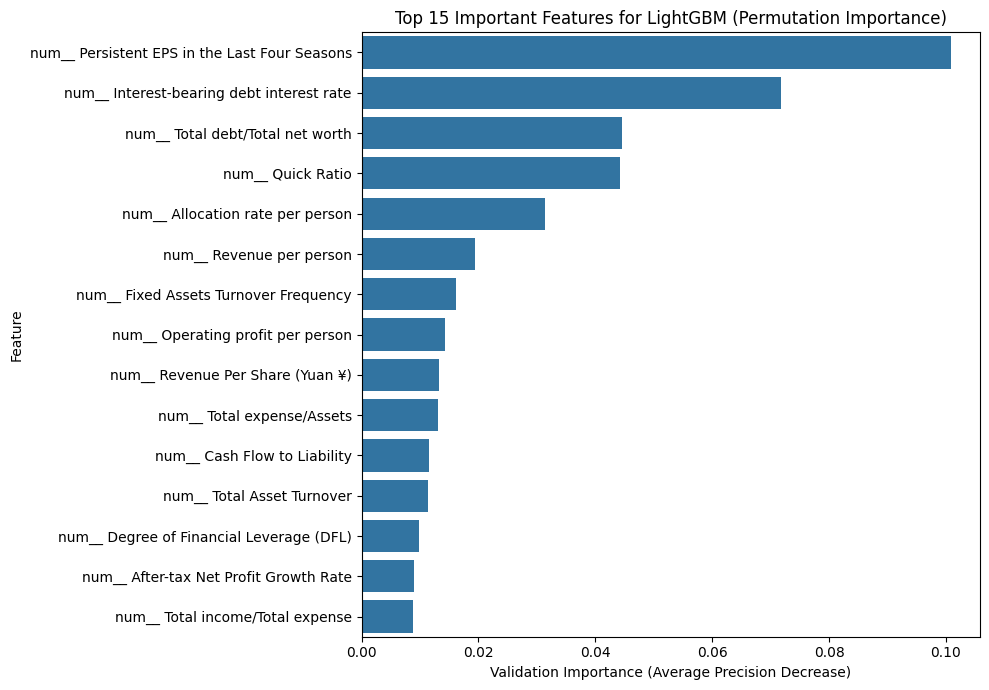

In [127]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="importance_mean",
    y="feature",
    orient="h"
)
plt.title(f"Top 15 Important Features for {best_model_name} (Permutation Importance)")
plt.xlabel("Validation Importance (Average Precision Decrease)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [128]:
top_features[["feature", "importance_mean", "importance_std"]]


,feature,importance_mean,importance_std
0,num__ Persistent EPS in the Last Four Seasons,0.100780,0.040596
1,num__ Interest-bearing debt interest rate,0.071845,0.037807
2,num__ Total debt/Total net worth,0.044493,0.041055
3,num__ Quick Ratio,0.044194,0.034136
4,num__ Allocation rate per person,0.031471,0.008137
5,num__ Revenue per person,0.019489,0.011318
6,num__ Fixed Assets Turnover Frequency,0.016162,0.009967
7,num__ Operating profit per person,0.014319,0.006407
8,num__ Revenue Per Share (Yuan ¥),0.013199,0.013781
9,num__ Total expense/Assets,0.013038,0.010169


### 10.9 Model Card for the Final Selected Model
**Goal:** Summarise the final selected model in a concise model card, covering what the model is, why it was chosen, how it was trained and validated, and the main limitations to keep in mind.

In [129]:
if "best_model_name" not in globals():
    raise ValueError("best_model_name is not available. Please run the model comparison section first.")

best_row = model_results[model_results["model"] == best_model_name].iloc[0]

decision_threshold = 0.5

model_card = pd.DataFrame({
    "field": [
        "Model name",
        "Why chosen",
        "Dataset",
        "Target variable",
        "Task type",
        "Main preprocessing steps",
        "Class imbalance handling",
        "Training data used",
        "Validation data used",
        "Test data used",
        "Key validation results",
        "Decision threshold",
        "Limitations"
    ],
    "value": [
        best_model_name,
        "Chosen because it achieved the strongest validation performance on imbalance-aware metrics relevant to bankruptcy prediction.",
        "Taiwanese bankruptcy prediction dataset based on financial ratios",
        "Bankrupt?",
        "Binary classification",
        "Training-set-only preprocessing with imputation and application of the fitted transformations to validation data only.",
        "Imbalance handled through model-level class weighting or scale_pos_weight.",
        "Training split only",
        "Validation split only",
        "Not used",
        (
            f"Balanced Accuracy={best_row['balanced_accuracy']:.4f}, "
            f"Precision={best_row['precision']:.4f}, "
            f"Recall={best_row['recall']:.4f}, "
            f"F1={best_row['f1']:.4f}, "
            f"ROC-AUC={best_row['roc_auc']:.4f}, "
            f"Average Precision={best_row['average_precision']:.4f}"
        ),
        decision_threshold,
        "Results are based only on train and validation data; performance may still be sensitive to class imbalance, feature quality, and threshold choice."
    ]
})

model_card

,field,value
0,Model name,LightGBM
1,Why chosen,Chosen because it achieved the strongest valid...
2,Dataset,Taiwanese bankruptcy prediction dataset based ...
3,Target variable,Bankrupt?
4,Task type,Binary classification
5,Main preprocessing steps,Training-set-only preprocessing with imputatio...
6,Class imbalance handling,Imbalance handled through model-level class we...
7,Training data used,Training split only
8,Validation data used,Validation split only
9,Test data used,Not used


## Section 11: Hyperparameter Tuning of the Final Selected Model

### 11.1 Prepare the Selected Untuned Model for Tuning
**Goal:** Take the best untuned model selected in Section 10 and set up a training-only tuning workflow without using the test set.


In [130]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

if "best_model_name" not in globals():
    raise ValueError("best_model_name is not available. Please run Section 10 first.")

if "X_train_prepared" not in globals() or "X_val_prepared" not in globals():
    raise ValueError("Prepared train/validation matrices are not available. Please run the Section 10 preprocessing step first.")

if best_model_name == "LightGBM":
    untuned_model = lgbm_model
elif best_model_name == "XGBoost":
    untuned_model = xgb_model
else:
    raise ValueError(f"Unsupported best_model_name: {best_model_name}")

main_metric = "average_precision"
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pd.DataFrame({
    "selected_untuned_model": [best_model_name],
    "tuning_data_used": ["Training set only"],
    "validation_set_used_for_search": ["No"],
    "test_set_used_for_search": ["No"],
    "optimisation_metric": [main_metric]
})

,selected_untuned_model,tuning_data_used,validation_set_used_for_search,test_set_used_for_search,optimisation_metric
0,LightGBM,Training set only,No,No,average_precision


**Interpretation:** The tuning stage begins only after the best untuned model has already been identified. Hyperparameter search uses the training set only, with cross-validation inside the training set.

### 11.2 Define a Reasonable Hyperparameter Search Space
**Goal:** Create a compact, defensible hyperparameter search space for the selected model that is appropriate for tabular imbalanced classification.


In [139]:
if best_model_name == "LightGBM":
    param_distributions = {
        "n_estimators": [200, 300, 500, 700],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "num_leaves": [15, 31, 63, 127],
        "max_depth": [-1, 4, 6, 8],
        "min_child_samples": [10, 20, 30, 50],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0.0, 0.1, 1.0],
        "reg_lambda": [0.0, 0.1, 1.0]
    }
elif best_model_name == "XGBoost":
    param_distributions = {
        "n_estimators": [200, 300, 500, 700],
        "learning_rate": [0.03, 0.05, 0.08, 0.1],
        "max_depth": [3, 4, 5, 6],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "gamma": [0.0, 0.1, 0.3],
        "reg_alpha": [0.0, 0.1, 1.0],
        "reg_lambda": [1.0, 2.0, 5.0]
    }

pd.DataFrame({
    "selected_model": [best_model_name],
    "search_type": ["RandomizedSearchCV"],
    "n_iter": [20],
    "cv_folds": [5]
})

,selected_model,search_type,n_iter,cv_folds
0,LightGBM,RandomizedSearchCV,20,5


**Interpretation:** The search space is intentionally moderate rather than excessive. It is large enough to improve the selected model meaningfully, but still concise and reproducible.

### 11.3 Tune the Selected Model Using Training Data Only
**Goal:** Run hyperparameter search on the training set only and optimise the project’s main metric without touching the validation or test sets during fitting.


In [140]:
tuning_search = RandomizedSearchCV(
    estimator=untuned_model.__class__(**untuned_model.get_params()),
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    n_jobs=-1,
    cv=cv,
    refit=True,
    random_state=42,
    verbose=0
)

tuning_search.fit(X_train_prepared, y_train_model)

tuned_model = tuning_search.best_estimator_
best_hyperparameters = tuning_search.best_params_

pd.DataFrame({
    "best_cv_average_precision": [tuning_search.best_score_],
    "selected_model": [best_model_name]
})

[LightGBM] [Info] Number of positive: 154, number of negative: 4619
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15045
[LightGBM] [Info] Number of data points in the train set: 4773, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

,best_cv_average_precision,selected_model
0,0.453273,LightGBM


In [141]:
pd.DataFrame({
    "hyperparameter": list(best_hyperparameters.keys()),
    "best_value": list(best_hyperparameters.values())
})

,hyperparameter,best_value
0,subsample,0.70
1,reg_lambda,0.10
2,reg_alpha,1.00
3,num_leaves,15.00
4,n_estimators,200.00
5,min_child_samples,20.00
6,max_depth,4.00
7,learning_rate,0.08
8,colsample_bytree,1.00


**Interpretation:** The validation set is still untouched here. The tuned model is selected purely from cross-validated training performance, which keeps the tuning stage leakage-safe.

### 11.4 Evaluate the Tuned Model on the Validation Set
**Goal:** Compare the tuned model against the untuned version on the validation set using the same imbalance-aware metrics and the same fixed decision threshold.


In [142]:
decision_threshold = 0.5

tuned_val_proba = tuned_model.predict_proba(X_val_prepared)[:, 1]
tuned_val_pred = (tuned_val_proba >= decision_threshold).astype(int)

tuned_validation_results = pd.DataFrame({
    "model": [f"{best_model_name} (Tuned)"],
    "balanced_accuracy": [balanced_accuracy_score(y_val_model, tuned_val_pred)],
    "precision": [precision_score(y_val_model, tuned_val_pred, zero_division=0)],
    "recall": [recall_score(y_val_model, tuned_val_pred, zero_division=0)],
    "f1": [f1_score(y_val_model, tuned_val_pred, zero_division=0)],
    "roc_auc": [roc_auc_score(y_val_model, tuned_val_proba)],
    "average_precision": [average_precision_score(y_val_model, tuned_val_proba)]
})

untuned_validation_results = model_results[model_results["model"] == best_model_name].copy()

comparison_tuned_vs_untuned = pd.concat(
    [untuned_validation_results, tuned_validation_results],
    ignore_index=True
)

comparison_tuned_vs_untuned

c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,LightGBM,0.692424,0.590909,0.393939,0.472727,0.956535,0.467044
1,LightGBM (Tuned),0.760101,0.418605,0.545455,0.473684,0.964402,0.518280


**Interpretation:** This is the correct place to compare tuned versus untuned performance, because validation is the holdout set reserved for model selection decisions before the final test evaluation.

### 11.5 Keep the Better Model as the Final Model
**Goal:** Select either the tuned or untuned version based on validation performance and record the final choice for downstream test evaluation and reporting.


In [143]:
untuned_ap = float(untuned_validation_results["average_precision"].iloc[0])
tuned_ap = float(tuned_validation_results["average_precision"].iloc[0])

untuned_roc = float(untuned_validation_results["roc_auc"].iloc[0])
tuned_roc = float(tuned_validation_results["roc_auc"].iloc[0])

untuned_recall = float(untuned_validation_results["recall"].iloc[0])
tuned_recall = float(tuned_validation_results["recall"].iloc[0])

if (
    (tuned_ap > untuned_ap) or
    (tuned_ap == untuned_ap and tuned_roc > untuned_roc) or
    (tuned_ap == untuned_ap and tuned_roc == untuned_roc and tuned_recall > untuned_recall)
):
    final_model = tuned_model
    final_model_name = best_model_name
    final_model_variant = "Tuned"
    final_model_display_name = f"{best_model_name} (Tuned)"
    final_validation_results = tuned_validation_results.copy()
    final_hyperparameters = best_hyperparameters
    final_choice_reason = "Chosen because the tuned model achieved better validation performance on the main metric."
else:
    final_model = untuned_model
    final_model_name = best_model_name
    final_model_variant = "Untuned"
    final_model_display_name = f"{best_model_name} (Untuned)"
    final_validation_results = untuned_validation_results.copy()
    final_hyperparameters = "Default hyperparameters from Section 10"
    final_choice_reason = "Chosen because tuning did not improve validation performance enough to justify replacing the untuned model."

pd.DataFrame({
    "final_model": [final_model_display_name],
    "choice_reason": [final_choice_reason],
    "decision_threshold": [decision_threshold]
})

,final_model,choice_reason,decision_threshold
0,LightGBM (Tuned),Chosen because the tuned model achieved better...,0.5


**Interpretation:** The final model is chosen strictly from training-plus-validation evidence. The test set is still untouched.

## Section 12: Final Evaluation on the Untouched Test Set

### 12.1 Apply the Existing Training-Fitted Preprocessing to the Test Set
**Goal:** Transform the untouched test set using the preprocessing already fitted on the training set only.

In [144]:
X_test_prepared = preprocessor.transform(X_test)

pd.DataFrame({
    "dataset": ["Test"],
    "rows": [X_test_prepared.shape[0]],
    "columns_after_preprocessing": [X_test_prepared.shape[1]],
    "test_set_used_for_tuning": ["No"]
})

,dataset,rows,columns_after_preprocessing,test_set_used_for_tuning
0,Test,1023,59,No


**Interpretation:** The test set is only transformed with the existing training-fitted preprocessor. No parameter is learned from the test set.

### 12.2 Evaluate the Final Selected Model on the Test Set
**Goal:** Produce the final test metrics, classification report, and confusion matrix using the exact final chosen model and fixed decision threshold.


In [145]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_proba = final_model.predict_proba(X_test_prepared)[:, 1]
y_test_pred = (y_test_proba >= decision_threshold).astype(int)

test_results = pd.DataFrame({
    "model": [final_model_display_name],
    "balanced_accuracy": [balanced_accuracy_score(y_test, y_test_pred)],
    "precision": [precision_score(y_test, y_test_pred, zero_division=0)],
    "recall": [recall_score(y_test, y_test_pred, zero_division=0)],
    "f1": [f1_score(y_test, y_test_pred, zero_division=0)],
    "roc_auc": [roc_auc_score(y_test, y_test_proba)],
    "average_precision": [average_precision_score(y_test, y_test_proba)]
})

test_results

c:\Users\tc012\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
0,LightGBM (Tuned),0.761111,0.439024,0.545455,0.486486,0.931099,0.456


In [146]:
test_classification_report = pd.DataFrame(
    classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
).T

test_classification_report

,precision,recall,f1-score,support
0,0.984725,0.976768,0.980730,990.000000
1,0.439024,0.545455,0.486486,33.000000
accuracy,0.962854,0.962854,0.962854,0.962854
macro avg,0.711875,0.761111,0.733608,1023.000000
weighted avg,0.967122,0.962854,0.964787,1023.000000


In [147]:
test_confusion_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

test_confusion_matrix

,Predicted 0,Predicted 1
Actual 0,967,23
Actual 1,15,18


**Interpretation:** These are the first and only final test results. No tuning, threshold adjustment, or feature changes are made using the test set.

### 12.3 Compare Validation and Test Performance
**Goal:** Compare validation and test performance for the final selected model to assess generalisation and identify possible signs of overfitting.


In [148]:
validation_vs_test = pd.DataFrame({
    "metric": [
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "validation": [
        float(final_validation_results["balanced_accuracy"].iloc[0]),
        float(final_validation_results["precision"].iloc[0]),
        float(final_validation_results["recall"].iloc[0]),
        float(final_validation_results["f1"].iloc[0]),
        float(final_validation_results["roc_auc"].iloc[0]),
        float(final_validation_results["average_precision"].iloc[0])
    ],
    "test": [
        float(test_results["balanced_accuracy"].iloc[0]),
        float(test_results["precision"].iloc[0]),
        float(test_results["recall"].iloc[0]),
        float(test_results["f1"].iloc[0]),
        float(test_results["roc_auc"].iloc[0]),
        float(test_results["average_precision"].iloc[0])
    ]
})

validation_vs_test["difference_test_minus_validation"] = (
    validation_vs_test["test"] - validation_vs_test["validation"]
)

validation_vs_test

,metric,validation,test,difference_test_minus_validation
0,Balanced Accuracy,0.760101,0.761111,0.001010
1,Precision,0.418605,0.439024,0.020420
2,Recall,0.545455,0.545455,0.000000
3,F1 Score,0.473684,0.486486,0.012802
4,ROC-AUC,0.964402,0.931099,-0.033303
5,Average Precision,0.518280,0.456000,-0.062280


**Interpretation:** If the test metrics remain close to the validation metrics, the final model generalises reasonably well. If the test performance drops materially, especially on `Recall`, `F1`, or `Average Precision`, that suggests overfitting or reduced robustness.

### 12.4 Updated Final Model Card
**Goal:** Summarise the final selected model after tuning and final test evaluation, including preprocessing, best hyperparameters, strengths, limitations, and why it is the final choice.


In [149]:
final_model_card = pd.DataFrame({
    "field": [
        "Model name",
        "Model variant",
        "Why chosen",
        "Dataset",
        "Target variable",
        "Task type",
        "Main preprocessing",
        "Class imbalance handling",
        "Training / validation setup",
        "Decision threshold",
        "Best hyperparameters",
        "Validation results",
        "Test results",
        "Strengths",
        "Limitations"
    ],
    "value": [
        final_model_name,
        final_model_variant,
        final_choice_reason,
        "Taiwanese bankruptcy prediction dataset based on financial ratios",
        "Bankrupt?",
        "Binary classification",
        "Training-fitted imputation, winsorisation, and scaling applied consistently to validation and test",
        "Model-level class weighting or scale_pos_weight, depending on the selected model",
        "Training set used for fitting and tuning; validation set used for model comparison; test set used only once for final evaluation",
        decision_threshold,
        final_hyperparameters,
        (
            f"Balanced Accuracy={float(final_validation_results['balanced_accuracy'].iloc[0]):.4f}, "
            f"Precision={float(final_validation_results['precision'].iloc[0]):.4f}, "
            f"Recall={float(final_validation_results['recall'].iloc[0]):.4f}, "
            f"F1={float(final_validation_results['f1'].iloc[0]):.4f}, "
            f"ROC-AUC={float(final_validation_results['roc_auc'].iloc[0]):.4f}, "
            f"Average Precision={float(final_validation_results['average_precision'].iloc[0]):.4f}"
        ),
        (
            f"Balanced Accuracy={float(test_results['balanced_accuracy'].iloc[0]):.4f}, "
            f"Precision={float(test_results['precision'].iloc[0]):.4f}, "
            f"Recall={float(test_results['recall'].iloc[0]):.4f}, "
            f"F1={float(test_results['f1'].iloc[0]):.4f}, "
            f"ROC-AUC={float(test_results['roc_auc'].iloc[0]):.4f}, "
            f"Average Precision={float(test_results['average_precision'].iloc[0]):.4f}"
        ),
        "Strong on tabular financial data, captures non-linear relationships, and is evaluated with imbalance-aware metrics.",
        "Performance remains sensitive to class imbalance, feature quality, and the fixed decision threshold; results are still dataset-specific."
    ]
})

final_model_card

,field,value
0,Model name,LightGBM
1,Model variant,Tuned
2,Why chosen,Chosen because the tuned model achieved better...
3,Dataset,Taiwanese bankruptcy prediction dataset based ...
4,Target variable,Bankrupt?
5,Task type,Binary classification
6,Main preprocessing,"Training-fitted imputation, winsorisation, and..."
7,Class imbalance handling,Model-level class weighting or scale_pos_weigh...
8,Training / validation setup,Training set used for fitting and tuning; vali...
9,Decision threshold,0.5


**Interpretation:** This updated model card reflects the actual final chosen model after tuning and final evaluation. It records the full path from preprocessing through validation and test performance without changing anything based on test results.